# Accelerated Machine Learning

This tutorial is based on the hls4ml tutorial notebooks (https://github.com/fastmachinelearning/hls4ml-tutorial/). The dataset is described in more detail in this article (https://iopscience.iop.org/article/10.1088/1748-0221/13/07/P07027/pdf). By the end of the course you will have:

* Trained a neural network to identify different types of "jets" at the Large Hadron Collider
* Used the hls4ml python library to convert the neural network to FPGA firmware
* Examined the FPGA resource usage for the neural network
* Understood floating point vs fixed point precision and the implications for inference accuracy and resource usage
* Implemented quantization-aware training using the QKeras library
* Tested the effect of "pruning" on the inference accuray and resource usage

## Part 1: Understanding the jet-tagging dataset

In this section we will import the dependencies and load the jet-tagging dataset. Following this we will take some time to understand the data.

In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import os
from matplotlib import pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os
import ndjson

2026-03-03 09:02:35.784219: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 09:02:36.174139: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-03 09:02:36.174211: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-03 09:02:36.176431: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 09:02:36.362384: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 09:02:36.365967: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Jets are one of the most important objects that we reconstruct at the Large Hadron Collider experiments. 
When fundamental particles, known as quarks or gluons, are produced in the proton-proton collisions,
they undergo a process called "hadronisation".
This creates narrow sprays of particles (hadrons) which are referred to as "jets".
By reconstructing and understanding these jets, we can infer properties of the fundamental particle interactions.
The image below shows a reconstruction of a collision event which produces two back-to-back jets with extremely high energy in the CMS detector.

In [2]:
# Load the dataset
data = fetch_openml('hls4ml_lhc_jets_hlf', version=1, as_frame=False, parser='liac-arff', cache=False)
X, y = data['data'], data['target']
labels = np.unique(y)
features = data['feature_names']

print("Number of jets:", len(X))
print("Number of features:", len(features))
print("Different target classes:", labels)

/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/sklearn/datasets/_openml.py:110: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/hls4ml_lhc_jets_hlf/limit/2/data_version/1. Retrying...
  warn(


Number of jets: 830000
Number of features: 16
Different target classes: ['g' 'q' 't' 'w' 'z']


In [3]:
import numpy as np

# Count number of jets per class
unique_classes, counts = np.unique(y, return_counts=True)

print("\nJets per class:")
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} jets ({count/len(y)*100:.2f}%)")


Jets per class:
Class g: 167125 jets (20.14%)
Class q: 161066 jets (19.41%)
Class t: 167851 jets (20.22%)
Class w: 167083 jets (20.13%)
Class z: 166875 jets (20.11%)


These correspond to jets produced from a gluon (q), light-quark (q), top-quark decay (t->bqq), W-boson decay (w->qq') and a Z-boson decay (z->qq). 
Jets from the different classes will have different substructure, and we can use this information for identification. We have five different classes to predict, each of which have a different distribution in the high-dimensional jet property phase space. Let's have a look at the 1D distributions for the different classes.

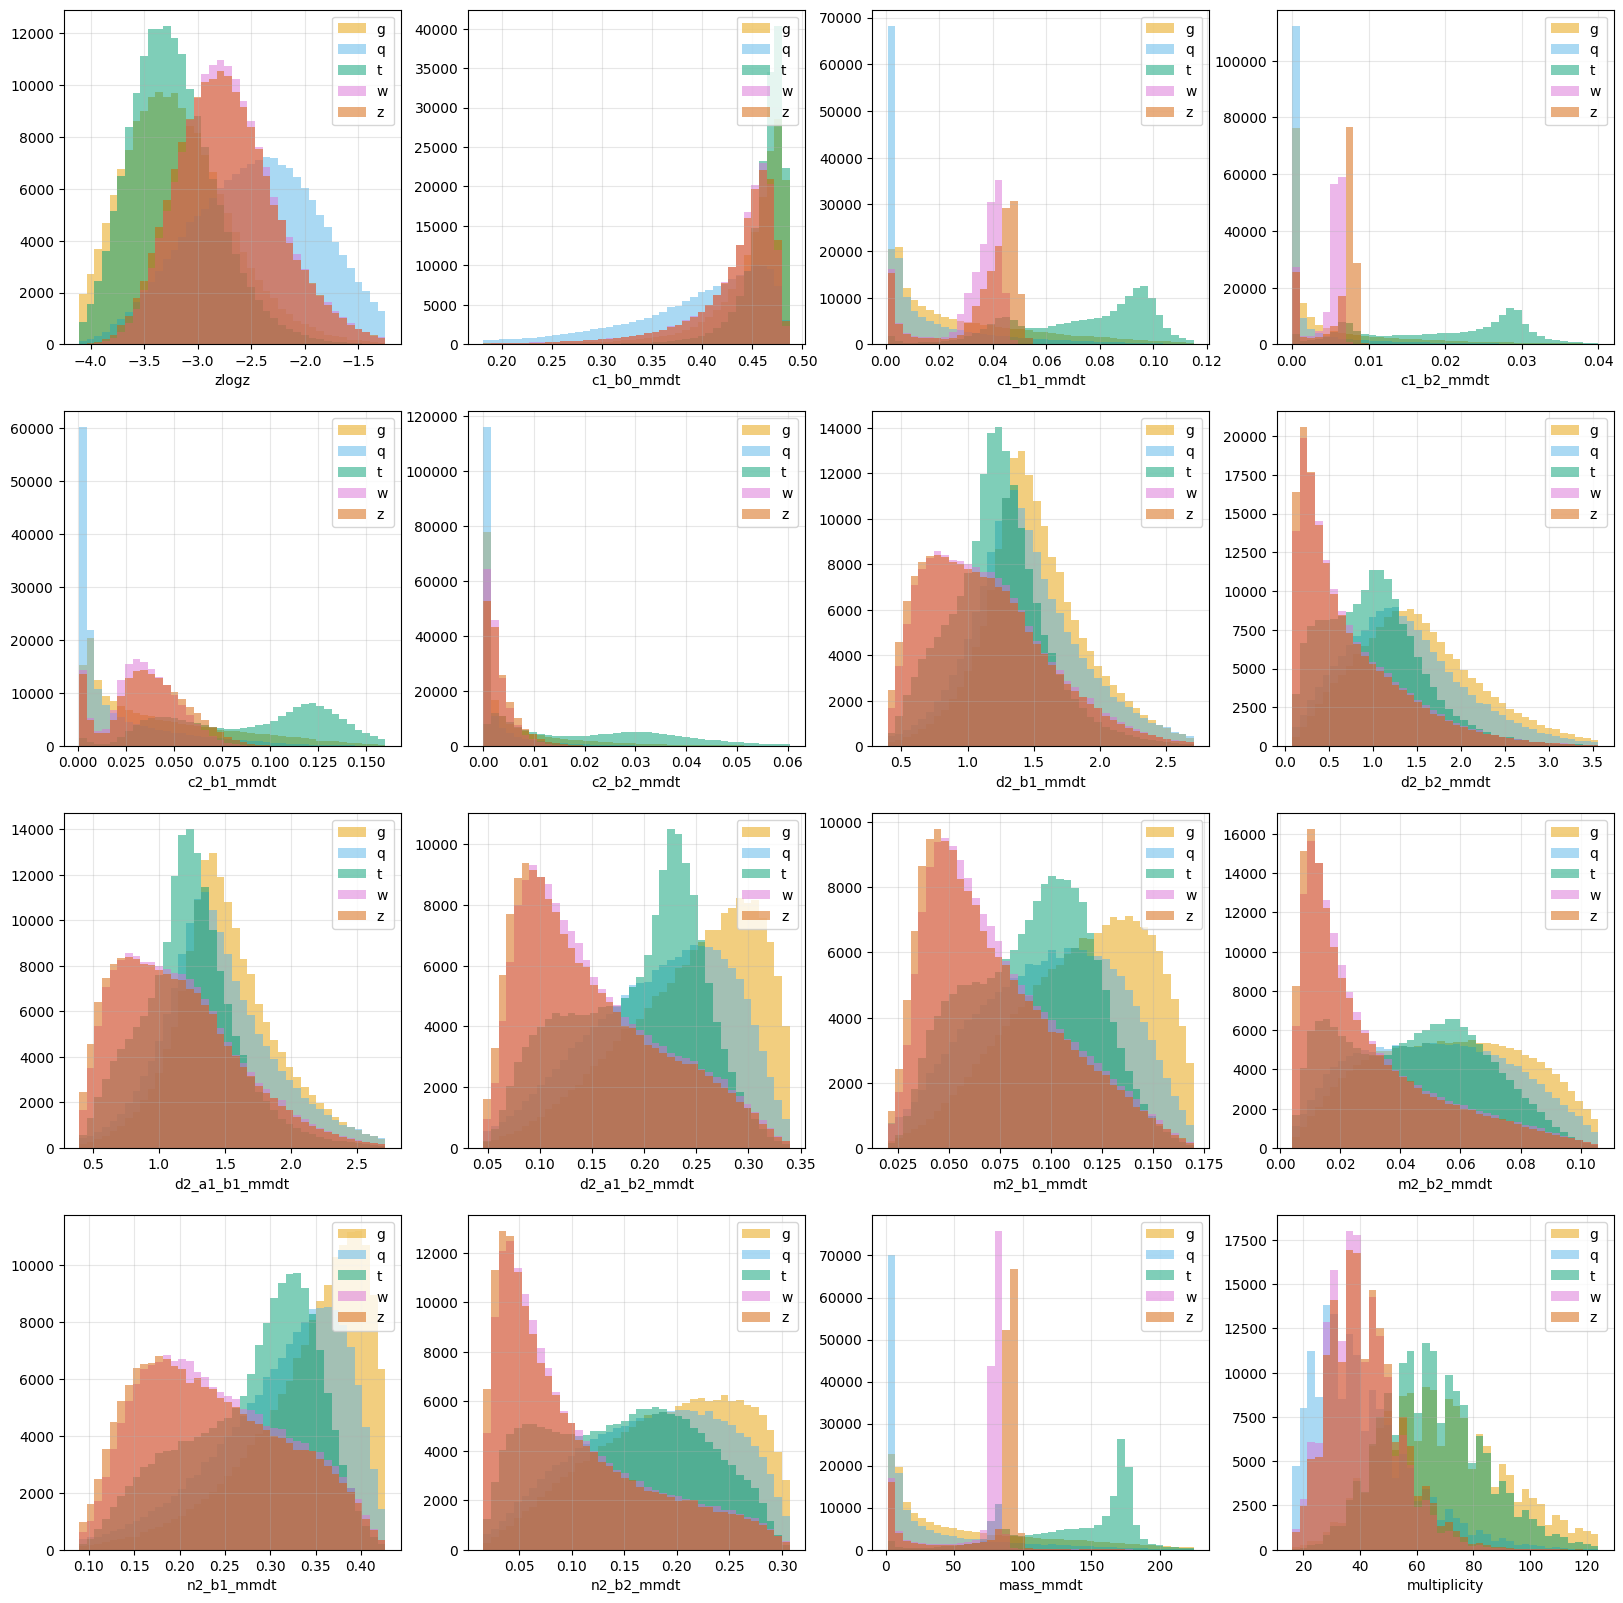

In [4]:
colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # green
    "orchid",  # pink/purple CC79A7
    "#D55E00",  # red/orange #D55E00
]

def plot_input_feature(ax, X, y, features, x="zlogz", classes=['g','q','t','w','z'], bins=40):
    fi = np.where(np.array(features)==x)[0][0]
    vals = X.T[fi]

    # Obtain percentiles for sensible plot
    xlo, xhi = np.percentile(vals,0.5), np.percentile(vals,99.5)

    for i, c in enumerate(classes):
        mask = (y == c)
        ax.hist(vals[mask], bins=bins, range=(xlo,xhi), label=c, color=colors[i], alpha=0.5)

    #ax.set_ylabel("Entries")
    ax.set_xlabel(x)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

fig, axs = plt.subplots(4,4, figsize=(20,20))
for k, feature in enumerate(features):
    i = int(np.floor(k/4))
    j = k%4
    plot_input_feature(axs[i][j], X, y, features, x=feature)

fig.savefig("features.png", dpi=300, bbox_inches="tight")
plt.show()

## Part 2: Creating a simple neural network for jet-tagging

We are going to use the 16-dimensional information in the dataset to classify the different kinds of jets.
Let's do this with a simple feed-forward multi-layer perceptron.

First we need to do a bit of pre-processing:

In [5]:
# Add categorical labels and do the test-train split
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.02, random_state=42)

# Do standard (z-score) scaling of the input features
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

# Save the datasets into the results folder for quick loading
np.save('results/X_train_val.npy', X_train_val)
np.save('results/X_test.npy', X_test)
np.save('results/y_train_val.npy', y_train_val)
np.save('results/y_test.npy', y_test)
np.save('results/classes.npy', le.classes_)

We will now load the relevant functionalities from tensorflow, and then build and train a neural network classifier.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1

In [7]:
# Build the classifier

# Creating an empty sequential model
model = Sequential()

# Adding the first layer, which adds a weight and bias to the input abd outputs 32 values, then an activation function
model.add(Dense(32, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

# Print summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 32)                544       
                                                                 
 relu1 (Activation)          (None, 32)                0         
                                                                 
 fc2 (Dense)                 (None, 32)                1056      
                                                                 
 relu2 (Activation)          (None, 32)                0         
                                                                 
 fc3 (Dense)                 (None, 32)                1056      
                                                                 
 relu3 (Activation)          (None, 32)                0         
                                                                 
 output (Dense)              (None, 5)                 1

In [8]:
# Train the network
N_epochs = 20
adam = Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

In [9]:
result = model.fit(
    X_train_val,
    y_train_val,
    batch_size=128,
    epochs=N_epochs,
    validation_split=0.25,
    shuffle=True,
)

Epoch 1/20
4767/4767 [==============================] - 15s 3ms/step - loss: 1.0308 - accuracy: 0.6496 - val_loss: 0.8686 - val_accuracy: 0.7192
Epoch 2/20
4767/4767 [==============================] - 14s 3ms/step - loss: 0.8329 - accuracy: 0.7268 - val_loss: 0.8134 - val_accuracy: 0.7323
Epoch 3/20
4767/4767 [==============================] - 14s 3ms/step - loss: 0.7968 - accuracy: 0.7360 - val_loss: 0.7889 - val_accuracy: 0.7392
Epoch 4/20
4767/4767 [==============================] - 14s 3ms/step - loss: 0.7781 - accuracy: 0.7414 - val_loss: 0.7753 - val_accuracy: 0.7429
Epoch 5/20
4767/4767 [==============================] - 14s 3ms/step - loss: 0.7663 - accuracy: 0.7452 - val_loss: 0.7650 - val_accuracy: 0.7460
Epoch 6/20
4767/4767 [==============================] - 14s 3ms/step - loss: 0.7576 - accuracy: 0.7475 - val_loss: 0.7579 - val_accuracy: 0.7485
Epoch 7/20
4767/4767 [==============================] - 15s 3ms/step - loss: 0.7507 - accuracy: 0.7497 - val_loss: 0.7510 - val_ac

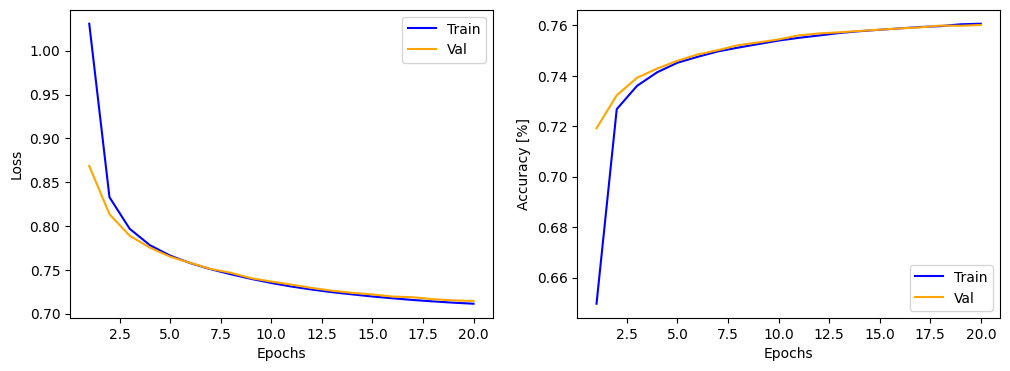

In [10]:
# Plot the training history
history = result.history

fig, axs = plt.subplots(1,2, figsize=(12,4))

epochs = np.linspace(1, N_epochs, N_epochs)
axs[0].plot(epochs, history['loss'], c='blue', label='Train')
axs[0].plot(epochs, history['val_loss'], c='orange', label='Val')
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend(loc='upper right')

axs[1].plot(epochs, history['accuracy'], c='blue', label='Train')
axs[1].plot(epochs, history['val_accuracy'], c='orange', label='Val')
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy [%]")
axs[1].legend(loc='lower right')

We should evaluate the performance on the test dataset to provide a "software" baseline. We calculate the global accuracy. This is defined as the fraction of correctly classified jets:

In [11]:
y_keras = model.predict(X_test)
keras_accuracy = np.sum(np.argmax(y_test, axis=1) == np.argmax(y_keras, axis=1))/y_test.shape[0]

print(f"Achieved test accuracy of {(100 * keras_accuracy):.2f}%")

519/519 [==============================] - 1s 2ms/step
Achieved test accuracy of 76.22%


In [12]:
from sklearn.metrics import roc_auc_score

# Per-class AUC (One-vs-Rest)
auc_per_class = roc_auc_score(y_test, y_keras, multi_class='ovr', average=None)
print("\nAUC per class:")
for i, auc in enumerate(auc_per_class):
    print(f"Class {i} AUC: {auc:.5f}")


AUC per class:
Class 0 AUC: 0.93743
Class 1 AUC: 0.89962
Class 2 AUC: 0.96231
Class 3 AUC: 0.95275
Class 4 AUC: 0.94593


In [13]:
auc_g, auc_q, auc_t, auc_w, auc_z = auc_per_class

In [14]:
auc_macro = roc_auc_score(y_test, y_keras, multi_class='ovr', average='macro')

print(f"\nMacro AUC: {auc_macro:.5f}")


Macro AUC: 0.93961


### Next Steps

1) Plotting the output probabilities from the neural network (multi-)classifier
2) Evaluating the ROC curves
3) Plotting the confusion matrix which tells us the fraction of predicted labels for each "truth" jet type

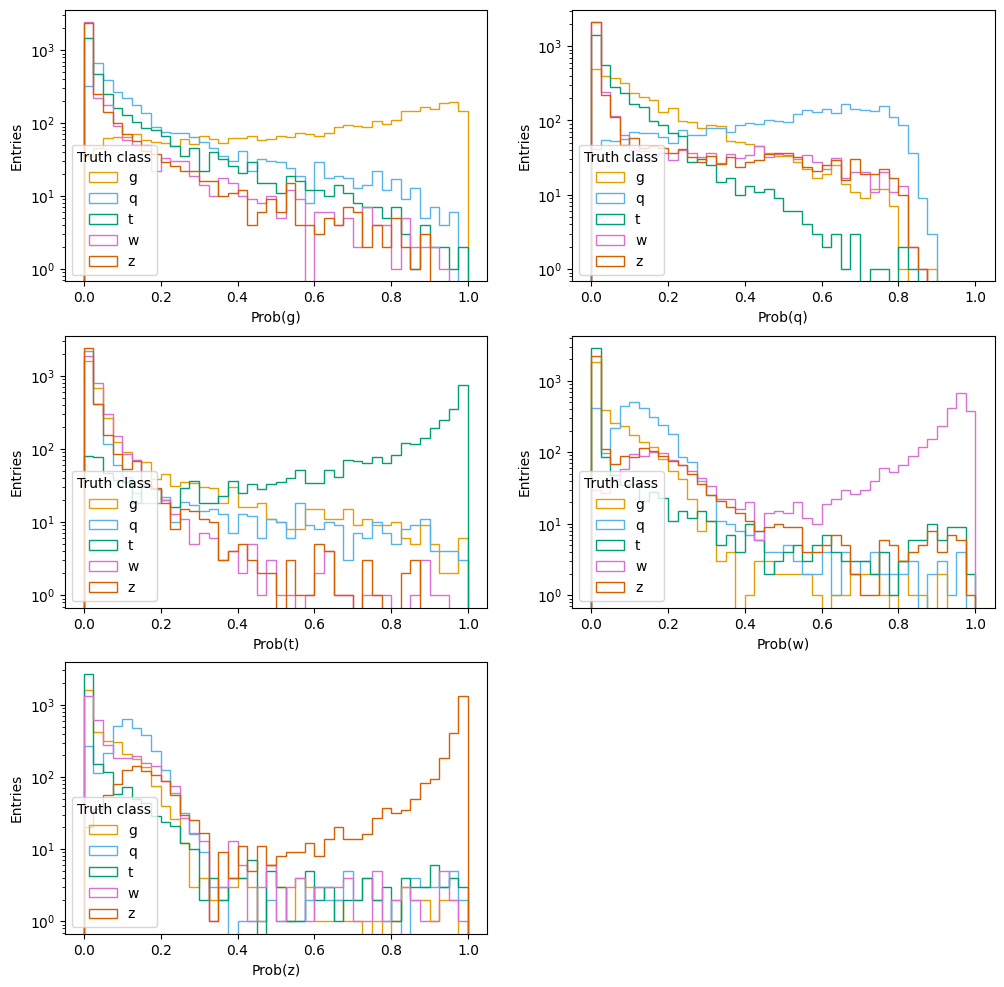

In [15]:
# Exercise 1

# Build masks for truth class
masks = {}
for truth_label in labels:
    masks[truth_label] = np.sum((labels == truth_label)*y_test, axis=1, dtype='bool')

fig, axs = plt.subplots(3,2, figsize=(12,12))
axs[2,1].axis('off')

# Loop over predicted classes and plot the probabilities from the classifier
# Store the probabilities for future use
probs = {}
for j, pred_label in enumerate(list(labels)):

    x = int(np.floor(j/2))
    y = j%2
    
    arg = np.where(labels==pred_label)[0][0]
    prob = y_keras.T[arg]
    probs[pred_label] = prob

    lo, hi = 0, 1

    # Plot probability distribution for each truth class
    for i, truth_label in enumerate(list(labels)):
        mask = masks[truth_label]
        axs[x][y].hist(prob[mask], bins=40, range=(lo,hi), label=truth_label, histtype='step', color=colors[i])

    axs[x][y].set_xlabel(f"Prob({pred_label})")
    axs[x][y].set_ylabel("Entries")
    axs[x][y].set_yscale("log")
    axs[x][y].legend(loc='lower left', title="Truth class")

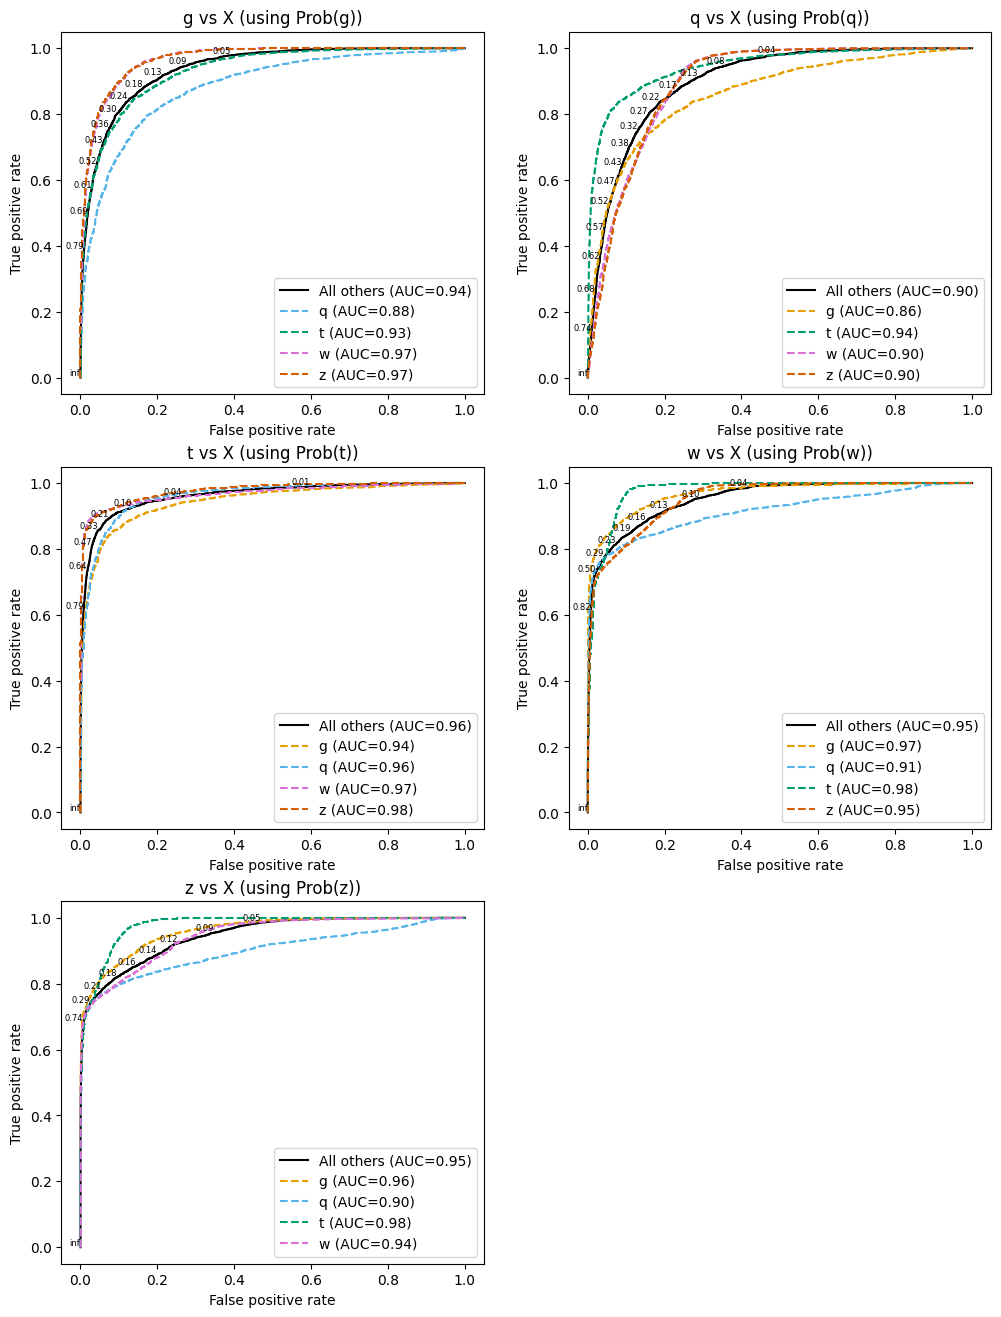

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axs = plt.subplots(3,2, figsize=(12,16))
axs[2,1].axis('off')

for j, label in enumerate(list(labels)):

    x = int(np.floor(j/2))
    y = j%2

    y_true = masks[label]
    y_pred = probs[label]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    axs[x][y].plot(fpr, tpr, label=f"All others (AUC={auc:.2f})", color='black')
    for i in range(0, len(thresholds), 200):
        axs[x][y].text(fpr[i], tpr[i], f"{thresholds[i]:.2f}", fontsize=6, ha='right', va='bottom', color='black')

    # Plot for each pair
    for other_label in labels:
        if other_label == label:
            continue

        mask_pair = masks[label]+masks[other_label]
        fpr, tpr, thresholds = roc_curve(y_true[mask_pair], y_pred[mask_pair])
        auc = roc_auc_score(y_true[mask_pair], y_pred[mask_pair])
        axs[x][y].plot(fpr, tpr, label=f"{other_label} (AUC={auc:.2f})", color=colors[np.where(labels==other_label)[0][0]], ls='--')

    axs[x][y].set_xlabel("False positive rate")
    axs[x][y].set_ylabel("True positive rate")
    axs[x][y].set_title(f"{label} vs X (using Prob({label}))")
    axs[x][y].legend(loc='lower right')

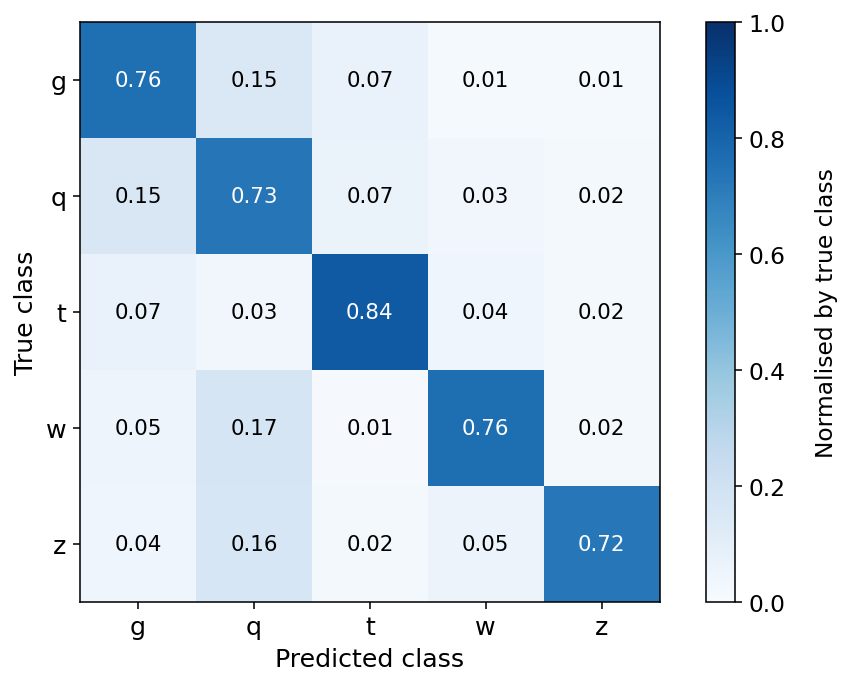

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_true_label = np.argmax(y_test, axis=1)
y_pred_label = np.argmax(y_keras, axis=1)

cm = confusion_matrix(y_true_label, y_pred_label, normalize='true')


fig, ax = plt.subplots(figsize=(7,5), dpi=140)
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Normalised by true class", fontsize=12, labelpad=15)
cbar.set_ticks(np.arange(0, 1.01, 0.2))
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, size=13)
ax.set_yticklabels(labels, size=13)
ax.set_xlabel('Predicted class', fontsize=13)
ax.set_ylabel('True class', fontsize=13)

# Auto-contrast text color based on cell intensity
threshold = cm.max() / 2.0  # switch color if cell > 50% max
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, f"{cm[i, j]:.2f}", ha='center', va='center', color=color, fontsize=11)

plt.tight_layout()
fig.savefig("confusion.png", dpi=300, bbox_inches="tight")
plt.show()


## Part 3: Online jet-tagging -- converting the model to FPGA firmware

In this section we convert the neural network trained with tensorflow into FPGA firmware. This is known as High-Level Synthesis (HLS) which allows us to write software-like code (e.g. in C, C++) and automatically compile it into hardware code (logic gates, registers, interconnects) that can be synthesized on an FPGA.

We will use the `hls4ml` package with an Intel OneAPI backend to do this. We have heard about these packages in the lecture slides. The tutorial will focus on optimising the resource usage, as latency tests require a full simulation of the data flow within the FPGA.

Before starting, there's one key property of FPGA algorithms which must be highlighted.

### Datatypes in HLS
Fixed point representation is used instead of floating point. For example the `hls4ml` default `fixed<16,6>` corresponds to:
```
+-------------------------+---------------------------+
|  Integer part (6 bits)  | Fractional part (10 bits) |
+-------------------------+---------------------------+
| 101010                  |                1010101010 |
+-------------------------+---------------------------+
|           Full bitwidth (16 bits)                   |
+-------------------------+---------------------------+
```
You can read more here: https://github.com/hlslibs/ac_types/blob/v3.7/pdfdocs/ac_datatypes_ref.pdf

This has important consequences for the synthesized models. At the end of this section we will see how the performance and resource-usage depend on bit-width length used for the network weights and biases during inference. In part 4, we will see how to incorporate bit-widths into the training process to maintain performance for a very small numbers of bits.

Let's set up the converter:

In [18]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='oneAPI')
print("-----------------------------------")
print("Configuration")
print(config)
print("-----------------------------------")

-----------------------------------
Configuration
{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}}
-----------------------------------


What do the different items in the configuration dictionary correspond to? The most important for you to understand are:

* `Precision`: specifies the numeric format to use in the generated hardware. This choice affects both resource usage and model accuracy. The precision can be specified globally (as shown above) or separate for each neural network layer.
* `ReuseFactor`: controls hardware reuse, such that `1` means no reuse i.e. the design uses as many hardware resources as needed to execute all operations in parallel. The lower this factor the faster the inference (lower latency) but more FPGA area (i.e. resources) is used. This factor can be tuned to meet the design constraints (parallelisation).
* `Strategy`: tells hls4ml to optimize for the lowest possible latency. Other strategies include `Resource`, which optimizes for minimal area.

We will now convert the keras model we trained for an Intel "Agilex7" FPGA, a family of high-end FPGAs which are designed for performance-demanding and power-efficient applications, like AI acceleration.

In [19]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='oneAPI', output_dir='model_1/hls4ml_prj', part='Agilex7'
)
hls_model.compile()

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_1/hls4ml_prj/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-8a84d1c2.so
[100%] Built target lib


Now that we have converted the model, we can evaluate the global accuracy (i.e. fraction of correctly classified jets). This should show little change from the software model.

In [20]:
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)

hls_accuracy = np.sum(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))/y_test.shape[0]

In [21]:
print(f"Achieved test accuracy of {(100 * hls_accuracy):.2f}%")

Achieved test accuracy of 76.25%


### Create a report of the FPGA resource usage

Now that we have a classifier which has been converted (and compiled) for use on an FPGA, we can emulate the design build and estimate the resource usage to see if it is compatible with our resource requirements. The report is produced in the project directory. We will will print out the key information from the build report.
* **Note**: ignore the seg fault

In [22]:
hls_model.build(build_type='report')

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_1/hls4ml_prj/build
[ 25%] To compile manually:
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/firmware/myproject.cpp -o CMakeFiles/report.dir/src/firmware/myproject.cpp.o
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/myproject_test.cpp -o CMakeFiles/report.dir/src/myproject_

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report


{'report': {'HLS': {'total': {'alut': 116417,
    'reg': 20476,
    'ram': 6,
    'dsp': 13,
    'mlab': 4},
   'available': {'alut': '974400',
    'reg': '1948800',
    'ram': '7110',
    'dsp': '4510',
    'mlab': '24360'}},
  'Loop': {'worstFrequency': '200.0', 'worstII': '1', 'worstLatency': '29.0'}}}

In [23]:
with open("model_1/hls4ml_prj/build/myproject.report.prj/reports/resources/json/summary.ndjson", "r") as f:
    summary = ndjson.load(f)

resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summary))[0]['columns'][1:-1]
available = list(filter(lambda x: x["name"] == "Available", summary))[0]['data'][:-1]
estimated_resources = list(filter(lambda x: x["name"] == "Total", summary))[0]['data'][:-1]

print("~~~~~~~~~~~~~~ Resource usage ~~~~~~~~~~~~~~")
for i, resource in enumerate(resource_names):
    print(f"--> {resource}:")
    print(f"      * Available resource: {available[i]}")
    print(f"      * Used resource (estimated): {estimated_resources[i]}")
    print(f"      * Percentage of used resource (estimated): {100*float(estimated_resources[i])/float(available[i]):.2f}%")

~~~~~~~~~~~~~~ Resource usage ~~~~~~~~~~~~~~
--> ALUTs :
      * Available resource: 974400
      * Used resource (estimated): 116417
      * Percentage of used resource (estimated): 11.95%
--> FFs  :
      * Available resource: 1948800
      * Used resource (estimated): 20476
      * Percentage of used resource (estimated): 1.05%
--> RAMs :
      * Available resource: 7110
      * Used resource (estimated): 6
      * Percentage of used resource (estimated): 0.08%
--> DSPs :
      * Available resource: 4510
      * Used resource (estimated): 13
      * Percentage of used resource (estimated): 0.29%
--> MLABs:
      * Available resource: 24360
      * Used resource (estimated): 4
      * Percentage of used resource (estimated): 0.02%


In [24]:
import os

json_dir = f"model_1/hls4ml_prj/build/myproject.report.prj/reports/resources/json/"
print(os.listdir(json_dir))

['lmv.ndjson', 'warnings.ndjson', 'summary.ndjson', 'pipeline.ndjson', 'area.ndjson', 'gmv.ndjson', 'block.ndjson', 'info.ndjson', 'file.ndjson', 'loops.ndjson', 'loop_attr.ndjson', 'quartus.ndjson', 'schedule.ndjson', 'mav.ndjson', 'new_lmv.ndjson', 'tree.ndjson', 'bottleneck.ndjson']


In [25]:
import ndjson

new_file = f"model_1/hls4ml_prj/build/myproject.report.prj/reports/resources/json/mav.ndjson"

with open(new_file, "r") as f:
    new_data = ndjson.load(f)

new_data

#import pandas as pd
#df = pd.DataFrame.from_dict(new_data, orient='index')

[{'id': -1,
  'depth': 0,
  'links': [{'from': 6, 'to': 5},
   {'from': 8, 'to': 7},
   {'from': 9, 'to': 10},
   {'from': 11, 'to': 12},
   {'from': 15, 'to': 5},
   {'from': 11, 'to': 16},
   {'from': 17, 'to': 11, 'reverse': 2},
   {'from': 5, 'to': 18, 'reverse': 2},
   {'from': 14, 'to': 13},
   {'from': 3, 'to': 13},
   {'from': 5, 'to': 14},
   {'from': 7, 'to': 14},
   {'from': 9, 'to': 14},
   {'from': 11, 'to': 14},
   {'from': 13, 'to': 5},
   {'from': 5, 'to': 7},
   {'from': 7, 'to': 9},
   {'from': 9, 'to': 11}]},
 {'type': 'kernel', 'id': 2, 'name': 'Myproject', 'parent': -1, 'depth': 1},
 {'type': 'bb',
  'id': 3,
  'name': 'Myproject.B0',
  'parent': 2,
  'depth': 2,
  'details': [{'type': 'table', 'Latency': '2'}]},
 {'type': 'bb',
  'id': 4,
  'name': 'Myproject.B1',
  'parent': 2,
  'depth': 2,
  'details': [{'type': 'table',
    'Latency': '29',
    'II': '1',
    'Subloops': 'No',
    'Pipelined': 'Yes',
    'Fmax Bottlenecks': 'No',
    'Loop Info': ''}]},
 {'typ

In [26]:
resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summary))[0]['columns'][1:-1]
available = list(filter(lambda x: x["name"] == "Available", summary))[0]['data'][:-1]
estimated_resources = list(filter(lambda x: x["name"] == "Total", summary))[0]['data'][:-1]

estimated_resources

[116417, 20476, 6, 13, 4]

The different resource types correspond to:
* ALUTs: adaptive look-up tables. Implement logic expressions/functions
* FFs: flip-flops. Store one bit of data; used for variables/registers
* RAMs: On-chip block RAMs. Used for storing network weights, activations etc.
* DSPs: Digital Signal Processing blocks. Optimized for multiply/add functionalities which are ideal for NN layers.
* MLABs: Memory Logic Array blocks. Small, distributed memory with lower latency and smaller capacity than RAMs.

A simple (reductive) guide for when compiling a neural network with hls4ml. If it uses:
* Many DSPs --> You are doing lots of multiple/add operations e.g. dense layers/convolutions
* Lots of RAMs/MLABs --> You are storing many activations, weights, or intermediate values.
* High ALUT/FF usage --> Your logic is complex e.g. control flow, state machines.

**So even a quite simple neural network design (only ~3000 trainable parameters) can take up a sizeable chunk of the FPGA.**
* How can we accelerate more complex ML algorithms without being limited by the resources?
* How can we store many ML algorithms on the same FPGA?

We need to think smarter in terms of the training!

## Numerical precision study
### Scaning integer bits

First fixing fractional bits to 8: 

In [27]:
float_auc_per_class = np.array([auc_g, auc_q, auc_t, auc_w, auc_z])
float_auc_macro = auc_macro

In [32]:
import copy
import numpy as np
import hls4ml
import ndjson
import os

# Integer-bit scan (fractional bits fixed)

fractional_bits = 8
integer_bits_list = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

hls_accuracy_list = []
hls_summary_list = []
y_pred_hls_list = []
precision_labels = []

for integer_bits in integer_bits_list:
    
    total_bits = integer_bits + fractional_bits
    
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f" --> Testing precision: fixed<{total_bits},{integer_bits}>")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    # Deep copy config
    config_tmp = copy.deepcopy(config)
    config_tmp['Model']['Precision']['default'] = f"fixed<{total_bits},{integer_bits}>"
    output_dir = f"model_intscan_{total_bits}_{integer_bits}"
    
    # Convert and compile the model
    hls_model_tmp = hls4ml.converters.convert_from_keras_model(
        model,
        hls_config=config_tmp,
        backend='oneAPI',
        output_dir=output_dir,
        part='Agilex7')
    
    hls_model_tmp.compile()
    
    # Predict
    X_test_contig = np.ascontiguousarray(X_test)
    y_hls = hls_model_tmp.predict(X_test_contig)

    # Store predictions
    y_pred_hls_list.append(y_hls)
    precision_labels.append(f"<{total_bits},{integer_bits}>")

    # Accuracy
    accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))
    hls_accuracy_list.append(accuracy)
    
    # Build and extract resource usage
    hls_model_tmp.build(build_type='report')
    report_path = f"{output_dir}/build/myproject.report.prj/reports/resources/json/summary.ndjson"
    with open(report_path, "r") as f:
        summary = ndjson.load(f)
    hls_summary_list.append(summary)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<10,2>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_intscan_10_2/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-d0e50894.so
[100%] Built target lib
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5n

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<11,3>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_intscan_11_3/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-474c27a0.so
[100%] Built target lib
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xso

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<12,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_intscan_12_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-731c20a7.so
[100%] Built target lib
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xso

...

[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<22,14>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_intscan_22_14/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-5ce9a88c.so
[100%] Built target lib
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-X

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<23,15>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_intscan_23_15/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-a89aa4d4.so
[100%] Built target lib
Unable to read project data. Exiting.
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Ag

Segmentation fault (core dumped)
Killed
Error: Verilog generator FAILED.
Refer to myproject.report.prj/logs/myproject_report.log for details.


llvm-foreach: 
icpx: error: fpga compiler command failed with exit code 1 (use -v to see invocation)
make[3]: *** [CMakeFiles/report.dir/build.make:113: myproject.report] Error 1
make[2]: *** [CMakeFiles/Makefile2:180: CMakeFiles/report.dir/all] Error 2
make[1]: *** [CMakeFiles/Makefile2:187: CMakeFiles/report.dir/rule] Error 2
make: *** [Makefile:163: report] Error 2


CalledProcessError: Command 'make report' returned non-zero exit status 2.

In [33]:
from sklearn.metrics import roc_auc_score

n_classes = y_test.shape[1]

auc_fraction_per_class = []
macro_auc_list = []
macro_auc_fraction = []

for y_pred_hls in y_pred_hls_list:
    
    # Compute fixed-point per-class AUC
    aucs = np.array([
        roc_auc_score(y_test[:, i], y_pred_hls[:, i])
        for i in range(n_classes)])
    
    # Macro AUC for this precision
    auc_macro_fixed = aucs.mean()
    
    # Fraction instead of difference
    auc_ratio = aucs / float_auc_per_class
    macro_ratio = auc_macro_fixed / float_auc_macro
    
    auc_fraction_per_class.append(auc_ratio)
    macro_auc_list.append(auc_macro_fixed)
    macro_auc_fraction.append(macro_ratio)

# Convert to numpy arrays
auc_fraction_per_class = np.array(auc_fraction_per_class)
macro_auc_list = np.array(macro_auc_list)
macro_auc_fraction = np.array(macro_auc_fraction)

print("Number of precision points:", len(macro_auc_fraction))

Number of precision points: 14


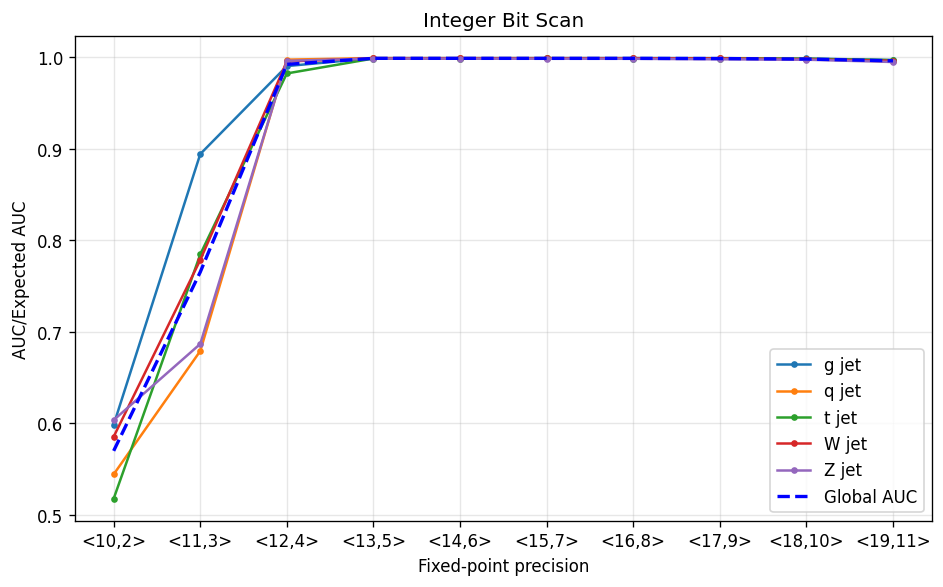

In [35]:
import matplotlib.pyplot as plt

n_classes = auc_fraction_per_class.shape[1]
x = range(len(precision_labels) -4)
jet_labels = ['g', 'q', 't', 'W', 'Z']

plt.figure(figsize=(8,5), dpi=120)

for i in range(n_classes):
    plt.plot(x, auc_fraction_per_class[:len(x), i], marker='.', label=f'{jet_labels[i]} jet')

plt.plot(x, macro_auc_fraction[:len(x)], linestyle = '--', linewidth = 2, color='blue', label='Global AUC')

plt.xticks(x, precision_labels[:len(x)])
plt.xlabel("Fixed-point precision")
plt.ylabel("AUC/Expected AUC")
#plt.ylim(-0.49, 0.05)
plt.title("Integer Bit Scan")
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [36]:
# Extracting resource usage

resource_usage = {}

for summ in hls_summary_list:
    resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summ))[0]['columns'][1:-1]
    available = list(filter(lambda x: x["name"] == "Available", summ))[0]['data'][:-1]
    estimated_resources = list(filter(lambda x: x["name"] == "Total", summ))[0]['data'][:-1]

    for i, resource in enumerate(resource_names):
        r = resource.split(" ")[0]
        usage_ratio = float(estimated_resources[i]) / float(available[i])
        
        if r not in resource_usage:
            resource_usage[r] = [usage_ratio]
        else:
            resource_usage[r].append(usage_ratio)

### Scaning fractional bits
Fixing integer bits to 6:

In [37]:
import copy
import numpy as np
import hls4ml
import ndjson
import os

# Fractional-bit scan (integer bits fixed)

integer_bits_fixed = 4
fractional_bits_list = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

hls_accuracy_frac = []
hls_summary_frac = []
y_pred_hls_frac = []
precision_labels_frac = []

for fractional_bits in fractional_bits_list:
    
    total_bits = integer_bits_fixed + fractional_bits
    
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f" --> Testing precision: fixed<{total_bits},{integer_bits_fixed}>")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    config_tmp = copy.deepcopy(config)
    config_tmp['Model']['Precision']['default'] = f"fixed<{total_bits},{integer_bits_fixed}>"
    output_dir = f"model_fracscan_{total_bits}_{integer_bits_fixed}"
    
    # Convert model
    hls_model_tmp = hls4ml.converters.convert_from_keras_model(
        model,
        hls_config=config_tmp,
        backend='oneAPI',
        output_dir=output_dir,
        part='Agilex7')
    
    hls_model_tmp.compile()
    
    # Predictions
    X_test_contig = np.ascontiguousarray(X_test)
    y_hls = hls_model_tmp.predict(X_test_contig)
    
    y_pred_hls_frac.append(y_hls)
    precision_labels_frac.append(f"<{total_bits},{integer_bits_fixed}>")
    
    # Accuracy
    accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))
    hls_accuracy_frac.append(accuracy)
    
    # Build for resource usage
    hls_model_tmp.build(build_type='report')
    report_path = f"{output_dir}/build/myproject.report.prj/reports/resources/json/summary.ndjson"
    with open(report_path, "r") as f:
        summary = ndjson.load(f)
    
    hls_summary_frac.append(summary)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<10,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (2.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_10_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building C

Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<11,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_11_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproj

Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<12,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_12_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproj

...

[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<18,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_18_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproj

Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<19,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_19_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproj

Segmentation fault (core dumped)


[100%] Built target report


In [38]:
from sklearn.metrics import roc_auc_score

n_classes = y_test.shape[1]

# Containers (NEW variable names)
auc_fraction_per_class_frac = []
macro_auc_list_frac = []
macro_auc_fraction_frac = []

for y_pred_hls in y_pred_hls_frac:
    
    # Per-class AUC for this fractional precision
    aucs = np.array([
        roc_auc_score(y_test[:, i], y_pred_hls[:, i])
        for i in range(n_classes)
    ])
    
    # Macro AUC
    auc_macro_fixed = aucs.mean()
    
    # Fraction (fixed / float)
    auc_ratio = aucs / float_auc_per_class
    macro_ratio = auc_macro_fixed / float_auc_macro
    
    auc_fraction_per_class_frac.append(auc_ratio)
    macro_auc_list_frac.append(auc_macro_fixed)
    macro_auc_fraction_frac.append(macro_ratio)

# Convert to numpy arrays
auc_fraction_per_class_frac = np.array(auc_fraction_per_class_frac)
macro_auc_list_frac = np.array(macro_auc_list_frac)
macro_auc_fraction_frac = np.array(macro_auc_fraction_frac)

print("Number of fractional precision points:", len(macro_auc_fraction_frac))

Number of fractional precision points: 10


In [40]:
fractional_bits = 5
integer_bits_fixed = 4
total_bits = integer_bits_fixed + fractional_bits

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
print(f" --> Testing precision: fixed<{total_bits},{integer_bits_fixed}>")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

config_tmp = copy.deepcopy(config)
config_tmp['Model']['Precision']['default'] = f"fixed<{total_bits},{integer_bits_fixed}>"
output_dir = f"model_fracscan_{total_bits}_{integer_bits_fixed}"

# Convert
hls_model_tmp = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config_tmp,
    backend='oneAPI',
    output_dir=output_dir,
    part='Agilex7')

hls_model_tmp.compile()

# Predict
X_test_contig = np.ascontiguousarray(X_test)
y_hls = hls_model_tmp.predict(X_test_contig)

y_pred_hls_frac.append(y_hls)
precision_labels_frac.append(f"<{total_bits},{integer_bits_fixed}>")

# Accuracy
accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))
hls_accuracy_frac.append(accuracy)

# Build report
hls_model_tmp.build(build_type='report')
report_path = f"{output_dir}/build/myproject.report.prj/reports/resources/json/summary.ndjson"

with open(report_path, "r") as f:
    summary = ndjson.load(f)

hls_summary_frac.append(summary)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Testing precision: fixed<9,4>
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx


/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/hls4ml/backends/fpga/passes/fix_softmax_table_size.py:38: UserWarning: Softmax layer softmax table size is too large for inputbitwidth 9. Setting table size to 512.To avoid this warning, please increase input bitwidth ordecrease table size.
  warnings.warn(


-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.6s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_fracscan_9_4/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-664622f5.so
[100%] Built target lib
/opt/intel/one

Segmentation fault (core dumped)


[100%] Built target report


In [41]:
auc_fraction_per_class_frac = []
macro_auc_list_frac = []
macro_auc_fraction_frac = []

for y_pred_hls in y_pred_hls_frac:

    aucs = np.array([
        roc_auc_score(y_test[:, i], y_pred_hls[:, i])
        for i in range(n_classes)
    ])

    auc_macro_fixed = aucs.mean()

    auc_ratio = aucs / float_auc_per_class
    macro_ratio = auc_macro_fixed / float_auc_macro

    auc_fraction_per_class_frac.append(auc_ratio)
    macro_auc_list_frac.append(auc_macro_fixed)
    macro_auc_fraction_frac.append(macro_ratio)

auc_fraction_per_class_frac = np.array(auc_fraction_per_class_frac)
macro_auc_fraction_frac = np.array(macro_auc_fraction_frac)

In [43]:
# Extract total bits from labels
bit_values = [int(label.split(',')[0][1:]) for label in precision_labels_frac]

# Sort everything by bit width
sorted_indices = np.argsort(bit_values)

precision_labels_frac = [precision_labels_frac[i] for i in sorted_indices]
auc_fraction_per_class_frac = auc_fraction_per_class_frac[sorted_indices]
macro_auc_fraction_frac = macro_auc_fraction_frac[sorted_indices]

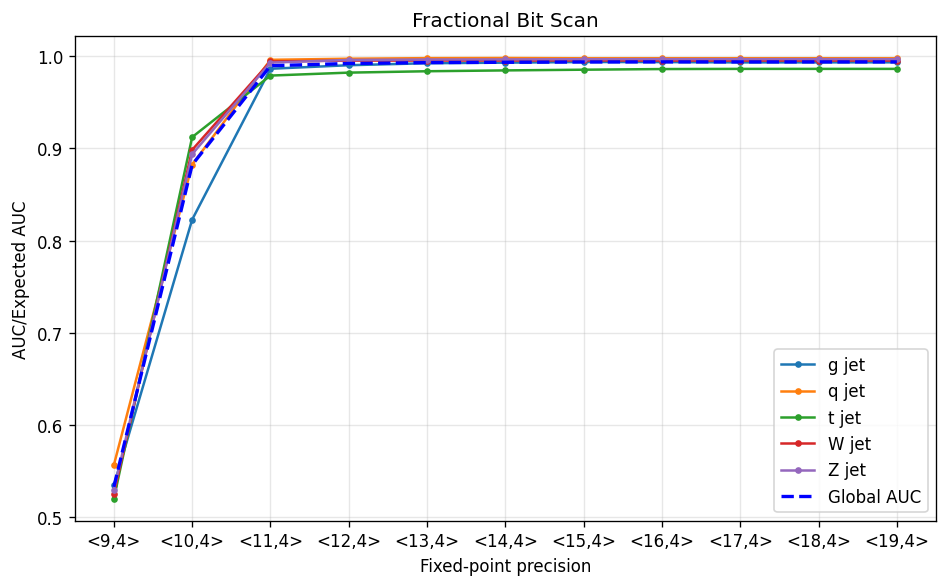

In [44]:
import matplotlib.pyplot as plt

n_classes = auc_fraction_per_class_frac.shape[1]
x = range(len(precision_labels_frac) )
jet_labels = ['g', 'q', 't', 'W', 'Z']

plt.figure(figsize=(8,5), dpi=120)

for i in range(n_classes):
    plt.plot(x, auc_fraction_per_class_frac[:len(x), i], marker='.', label=f'{jet_labels[i]} jet')

plt.plot(x, macro_auc_fraction_frac[:len(x)], linestyle = '--', linewidth = 2, color='blue', label='Global AUC')

plt.xticks(x, precision_labels_frac[:len(x)])
plt.xlabel("Fixed-point precision")
plt.ylabel("AUC/Expected AUC")
#plt.ylim(-0.49, 0.05)
plt.title("Fractional Bit Scan")
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

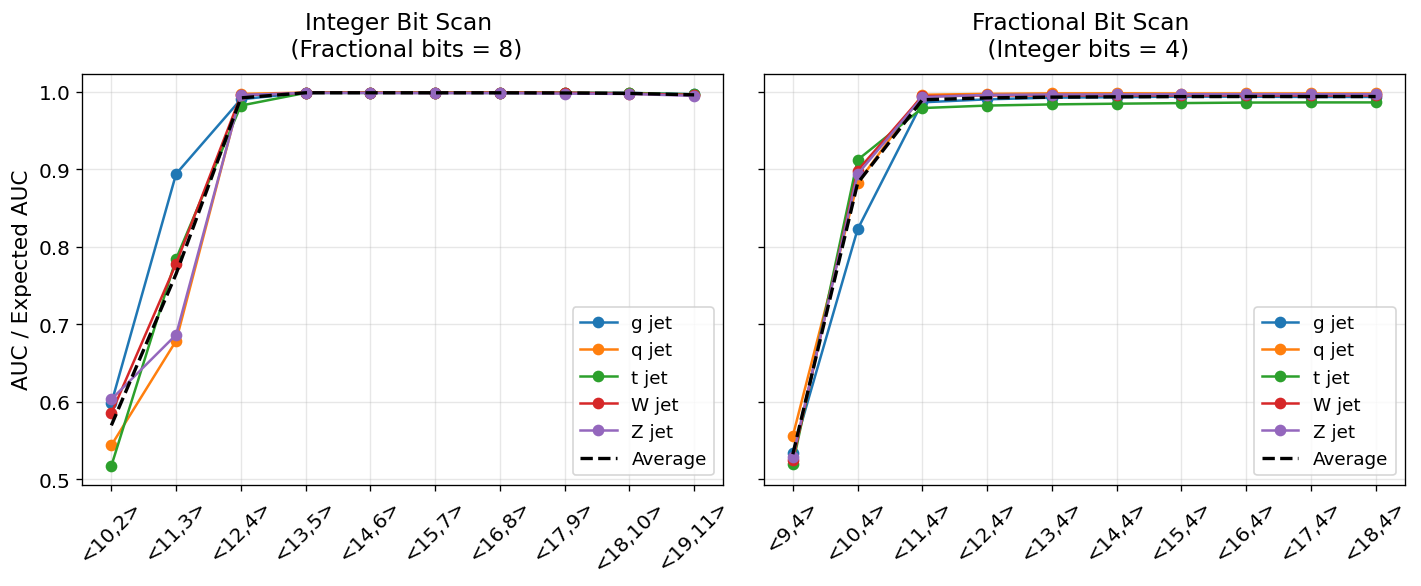

In [64]:
import matplotlib.pyplot as plt

jet_labels = ['g', 'q', 't', 'W', 'Z']

x_int = range(len(precision_labels) - 4)
x_frac = range(len(precision_labels_frac) - 1)

# Creating side-by-side subplots with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, sharey=True)

# Left: Integer Bit Scan
for i in range(auc_fraction_per_class.shape[1]):
    axes[0].plot(x_int, auc_fraction_per_class[:len(x_int), i], marker='o', label=f'{jet_labels[i]} jet')

axes[0].plot(x_int, macro_auc_fraction[:len(x_int)], linestyle='--', linewidth=2, color='k', label='Average')
axes[0].set_xticks(x_int)
axes[0].set_xticklabels(precision_labels[:len(x_int)], rotation=45, size=12)
#axes[0].set_xlabel("Fixed-point precision")
axes[0].set_ylabel("AUC / Expected AUC", fontsize=13)
axes[0].set_title("Integer Bit Scan \n (Fractional bits = 8)", y=1.02, fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='lower right', fontsize=11)

# Right: Fractional Bit Scan
for i in range(auc_fraction_per_class_frac.shape[1]):
    axes[1].plot(x_frac, auc_fraction_per_class_frac[:len(x_frac), i], marker='o', label=f'{jet_labels[i]} jet')

axes[1].plot(x_frac, macro_auc_fraction_frac[:len(x_frac)], linestyle='--', linewidth=2, color='k', label='Average')
axes[1].set_xticks(x_frac)
axes[1].set_xticklabels(precision_labels_frac[:len(x_frac)], rotation=45, size=12)
axes[1].set_title("Fractional Bit Scan \n (Integer bits = 4)", y=1.02, fontsize=14)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='lower right', fontsize=11)

axes[0].tick_params(axis='y', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)
plt.tight_layout()
fig.savefig("intfrac_new.png", dpi=300, bbox_inches="tight")
plt.show()

## Part 4: Quantization-Aware Training

In the previous exercise we have seen the trade-off between accuracy and resource usage when using different bit-widths **during inference**.

As discussed in the lecture slides, we can achieve similar levels of accuracy with significantly lower bit widths by **quantizing during the network training**. We will use the QKeras library to emulate fixed-point quantization during the forward pass of the training process. This ensures that network learns to optimally classify the different jet types within the fixed bit-width budget.

By lowering the bit widths we can:
* Reduce the resource usage (lower memory footprint)
* Speed up the inference process (reduce latency)

These are essential for AI acceleration using FPGAs! Let's start by importing the `qkeras` library. We will then look at how the `quantized_bit` behaves vs the full floating point equivalent.

In [28]:
import qkeras
from qkeras import QDense
from qkeras.quantizers import quantized_bits

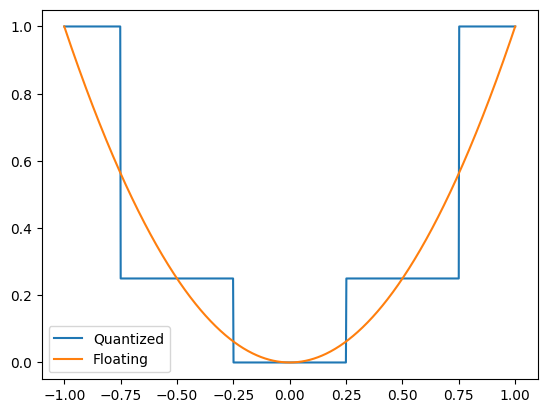

In [29]:
fig, ax = plt.subplots()
ax.plot(np.linspace(-1,1,1000), quantized_bits(3,1,1,alpha=1)(np.linspace(-1,1,1000))**2)
ax.plot(np.linspace(-1,1,1000), np.linspace(-1,1,1000)**2)

ax.legend(["Quantized", "Floating"])

### Creating a quantized model

To create a "quantized" neural network we using the `QDense` layer. This requires setting the `kernel_quantizer` and `bias_quantizer`, which control how the layer's weights and biases are quantized, respectively i.e. how they are converted from full-precision floating-point numbers to lower-bit fixed-point formats during training and inference.

We will reduce the model size substantially by only using 4 bits (1 integer) for each weight and bias in the network. This means each weight and bias can only take 1 of 16 different values (as shown in the plot above). Note, the number of training parameters does not change.

In [30]:
qmodel = Sequential()
qmodel.add(QDense(32, input_shape=(16,),
                  name='fc1',
                  kernel_quantizer = quantized_bits(4,1,1,alpha=1),
                  bias_quantizer = quantized_bits(4,1,1,alpha=1),
                  kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
qmodel.add(Activation(activation='relu', name='relu1'))
qmodel.add(QDense(32, 
                  name='fc2', 
                  kernel_quantizer = quantized_bits(4,1,1,alpha=1),
                  bias_quantizer = quantized_bits(4,1,1,alpha=1),                  
                  kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
qmodel.add(Activation(activation='relu', name='relu2'))
qmodel.add(QDense(32, 
                  name='fc3', 
                  kernel_quantizer = quantized_bits(4,1,1,alpha=1),
                  bias_quantizer = quantized_bits(4,1,1,alpha=1),                  
                  kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
qmodel.add(Activation(activation='relu', name='relu3'))
qmodel.add(QDense(5, 
                  name='output', 
                  kernel_quantizer = quantized_bits(4,1,1,alpha=1),
                  bias_quantizer = quantized_bits(4,1,1,alpha=1),                  
                  kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
qmodel.add(Activation(activation='softmax', name='softmax'))

qmodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 32)                544       
                                                                 
 relu1 (Activation)          (None, 32)                0         
                                                                 
 fc2 (QDense)                (None, 32)                1056      
                                                                 
 relu2 (Activation)          (None, 32)                0         
                                                                 
 fc3 (QDense)                (None, 32)                1056      
                                                                 
 relu3 (Activation)          (None, 32)                0         
                                                                 
 output (QDense)             (None, 5)                

Now let's train the network. With qkeras the fixed-point format is only used for the forward pass, and we revert back to the floating-point format for the backwards pass (backpropagation). This ensures that the loss is smooth and differentiable, with respect to the network weights and biases.

In [31]:
adam = Adam(learning_rate=0.0001)
qmodel.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# We will initialise with the weights from the full floating-points model (translated into the quantized_bit format)
qmodel.set_weights(model.get_weights())

In [32]:
N_epochs = 20
result_qkeras = qmodel.fit(
    X_train_val,
    y_train_val,
    batch_size=128,
    epochs=N_epochs,
    validation_split=0.25,
    shuffle=True,
)

Epoch 1/20
4767/4767 [==============================] - 19s 4ms/step - loss: 0.7776 - accuracy: 0.7403 - val_loss: 0.7967 - val_accuracy: 0.7382
Epoch 2/20
4767/4767 [==============================] - 16s 3ms/step - loss: 0.7668 - accuracy: 0.7439 - val_loss: 0.7976 - val_accuracy: 0.7335
Epoch 3/20
4767/4767 [==============================] - 17s 4ms/step - loss: 0.7635 - accuracy: 0.7450 - val_loss: 0.7730 - val_accuracy: 0.7428
Epoch 4/20
4767/4767 [==============================] - 16s 3ms/step - loss: 0.7676 - accuracy: 0.7434 - val_loss: 0.7633 - val_accuracy: 0.7468
Epoch 5/20
4767/4767 [==============================] - 17s 3ms/step - loss: 0.7660 - accuracy: 0.7437 - val_loss: 0.7716 - val_accuracy: 0.7430
Epoch 6/20
4767/4767 [==============================] - 17s 3ms/step - loss: 0.7628 - accuracy: 0.7442 - val_loss: 0.7462 - val_accuracy: 0.7507
Epoch 7/20
4767/4767 [==============================] - 16s 3ms/step - loss: 0.7635 - accuracy: 0.7442 - val_loss: 0.7814 - val_ac

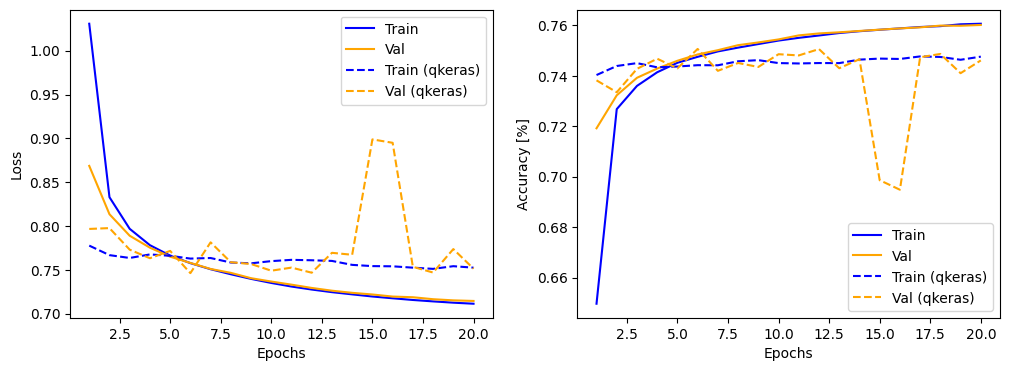

In [33]:
# Plot the training history and compare to the normal keras training
history_qkeras = result_qkeras.history

fig, axs = plt.subplots(1,2, figsize=(12,4))

epochs = np.linspace(1, N_epochs, N_epochs)
axs[0].plot(epochs, history['loss'], c='blue', label='Train')
axs[0].plot(epochs, history['val_loss'], c='orange', label='Val')
axs[0].plot(epochs, history_qkeras['loss'], c='blue', label='Train (qkeras)', ls='--')
axs[0].plot(epochs, history_qkeras['val_loss'], c='orange', label='Val (qkeras)', ls='--')
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend(loc='upper right')

axs[1].plot(epochs, history['accuracy'], c='blue', label='Train')
axs[1].plot(epochs, history['val_accuracy'], c='orange', label='Val')
axs[1].plot(epochs, history_qkeras['accuracy'], c='blue', label='Train (qkeras)', ls='--')
axs[1].plot(epochs, history_qkeras['val_accuracy'], c='orange', label='Val (qkeras)', ls='--')
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy [%]")
axs[1].legend(loc='lower right')

Now we can use the hls4ml package to convert the "quantized" network into FPGA firmware via HLS. The key difference is that we are now using a more complex configuration, with a separate config per layer name. For this we need to set the `granularity` argument to `"name"`. Let's set up the configuration and look at the contents (ignoring the warning):

In [34]:
config = hls4ml.utils.config_from_keras_model(qmodel, granularity='name', backend='oneAPI')
print("-----------------------------------")
print("Configuration")
print(config)
print("-----------------------------------")

-----------------------------------
Configuration
{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}, 'LayerName': {'fc1_input': {'Trace': False, 'Precision': {'result': 'auto'}}, 'fc1': {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'fixed<4,2,TRN,WRAP,0>', 'bias': 'fixed<4,2,TRN,WRAP,0>', 'accum': 'auto'}, 'ReuseFactor': 1}, 'fc1_linear': {'Trace': False, 'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'}, 'ReuseFactor': 1, 'TableSize': 1024}, 'relu1': {'Trace': False, 'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'}, 'ReuseFactor': 1, 'TableSize': 1024}, 'fc2': {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'fixed<4,2,TRN,WRAP,0>', 'bias': 'fixed<4,2,TRN,WRAP,0>', 'accum': 'auto'}, 'ReuseFactor': 1}, 'fc2_linear': {'Trace': False, 'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'}, 'ReuseFactor': 1, 'TableSize': 1024}, 'r

/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [35]:
# Let's do the HLS conversion
hls_model = hls4ml.converters.convert_from_keras_model(
    qmodel, hls_config=config, backend='oneAPI', output_dir='model_2/hls4ml_prj', part='Agilex7'
)
hls_model.compile()

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_2/hls4ml_prj/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-6aef3e54.so
[100%] Built target lib


In [36]:
# And evaluate the accuracy on the data set
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)

hls_accuracy = np.sum(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))/y_test.shape[0]

In [37]:
print(f"Achieved test accuracy of {(100 * hls_accuracy):.2f}%")

Achieved test accuracy of 74.73%


So we have managed to achieve roughly the same accuracy as the baseline model with much lower bit-widths.

Let's build the QKeras trained model and get an estimate for the resource usage.

In [38]:
hls_model.build(build_type='report')

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_2/hls4ml_prj/build
[ 25%] To compile manually:
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/firmware/myproject.cpp -o CMakeFiles/report.dir/src/firmware/myproject.cpp.o
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/myproject_test.cpp -o CMakeFiles/report.dir/src/myproject_

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report


{'report': {'HLS': {'total': {'alut': 29630,
    'reg': 7156,
    'ram': 6,
    'dsp': 0,
    'mlab': 4},
   'available': {'alut': '974400',
    'reg': '1948800',
    'ram': '7110',
    'dsp': '4510',
    'mlab': '24360'}},
  'Loop': {'worstFrequency': '200.0', 'worstII': '1', 'worstLatency': '22.0'}}}

In [39]:
with open("model_2/hls4ml_prj/build/myproject.report.prj/reports/resources/json/summary.ndjson", "r") as f:
    summary = ndjson.load(f)

resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summary))[0]['columns'][1:-1]
available = list(filter(lambda x: x["name"] == "Available", summary))[0]['data'][:-1]
estimated_resources = list(filter(lambda x: x["name"] == "Total", summary))[0]['data'][:-1]

print("~~~~~~~~~~~~~~ Resource usage ~~~~~~~~~~~~~~")
for i, resource in enumerate(resource_names):
    print(f"--> {resource}:")
    print(f"      * Available resource: {available[i]}")
    print(f"      * Used resource (estimated): {estimated_resources[i]}")
    print(f"      * Percentage of used resource (estimated): {float(estimated_resources[i])/float(available[i]):.2f}%")

resource_usage_qkeras = {}
for i,resource in enumerate(resource_names):
    r = resource.split(" ")[0]
    resource_usage_qkeras[r] = float(estimated_resources[i])/float(available[i])

~~~~~~~~~~~~~~ Resource usage ~~~~~~~~~~~~~~
--> ALUTs :
      * Available resource: 974400
      * Used resource (estimated): 29630
      * Percentage of used resource (estimated): 0.03%
--> FFs  :
      * Available resource: 1948800
      * Used resource (estimated): 7156
      * Percentage of used resource (estimated): 0.00%
--> RAMs :
      * Available resource: 7110
      * Used resource (estimated): 6
      * Percentage of used resource (estimated): 0.00%
--> DSPs :
      * Available resource: 4510
      * Used resource (estimated): 0
      * Percentage of used resource (estimated): 0.00%
--> MLABs:
      * Available resource: 24360
      * Used resource (estimated): 4
      * Percentage of used resource (estimated): 0.00%


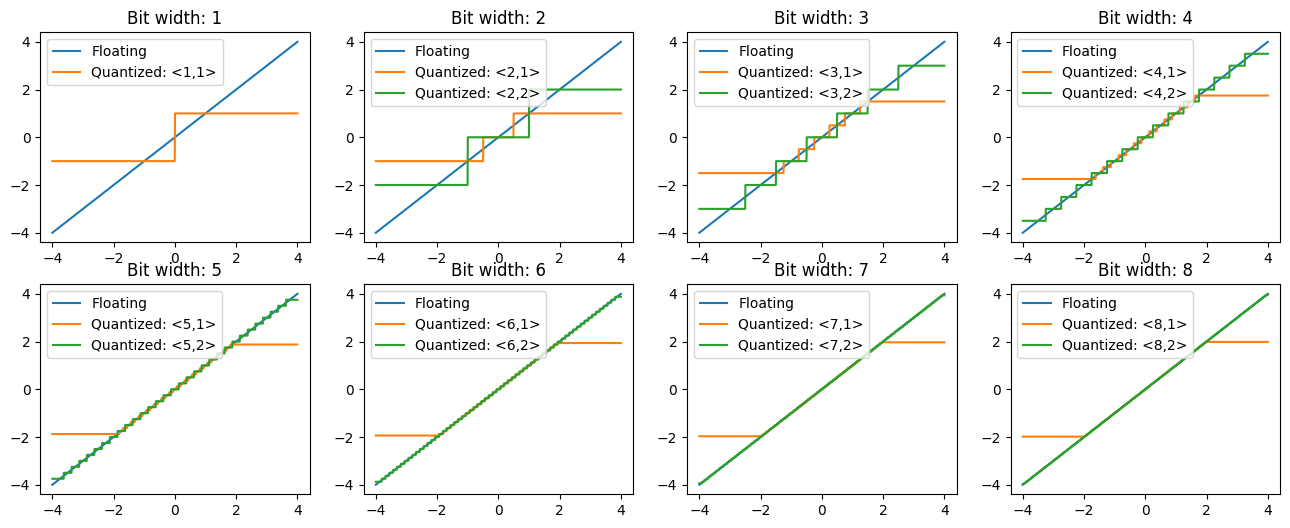

In [41]:
fig, axs = plt.subplots(2,4, figsize=(16,6))

for i in range(0,8):
    x = 0 if i < 4 else 1
    y = i % 4

    axs[x][y].plot(np.linspace(-4,4,1000), np.linspace(-4,4,1000))
    axs[x][y].plot(np.linspace(-4,4,1000), quantized_bits(i+1,1,1,alpha=1)(np.linspace(-4,4,1000)))
    if i > 0:
        axs[x][y].plot(np.linspace(-4,4,1000), quantized_bits(i+1,2,1,alpha=1)(np.linspace(-4,4,1000)))
    
    axs[x][y].set_title(f"Bit width: {i+1}")
    if i == 0:
        axs[x][y].legend(["Floating", "Quantized: <1,1>"])
    else:
        axs[x][y].legend(["Floating", f"Quantized: <{i+1},1>", f"Quantized: <{i+1},2>"])

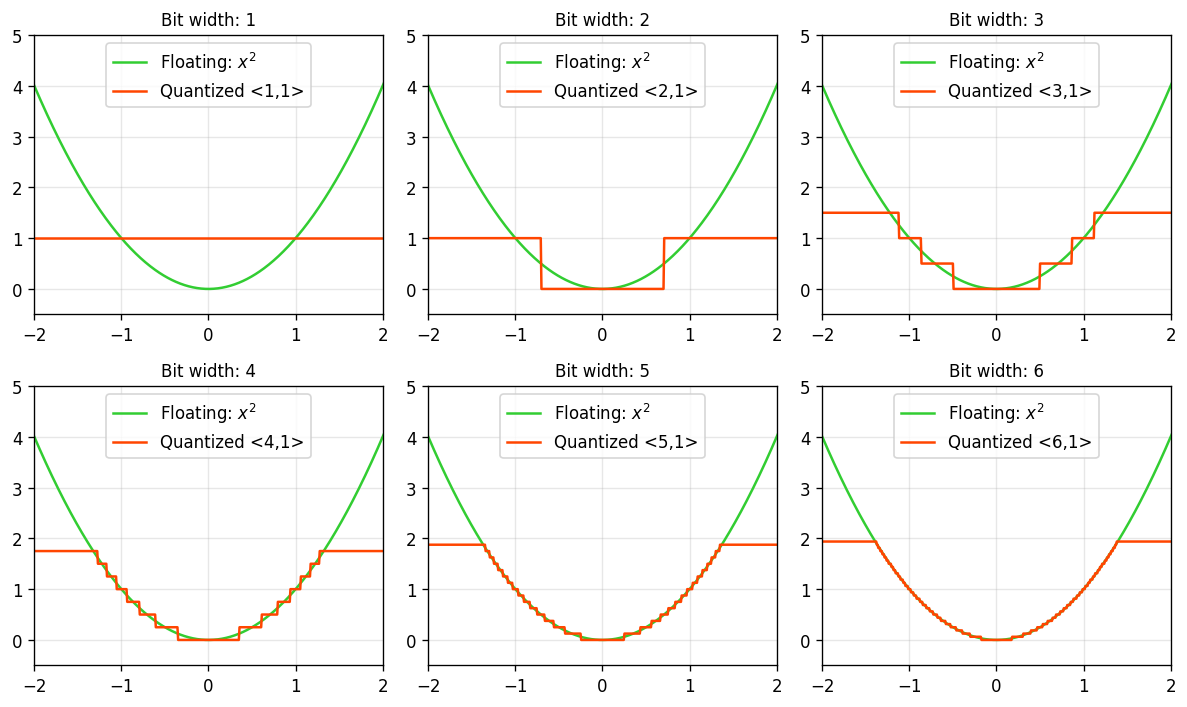

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from qkeras.quantizers import quantized_bits

fig, axs = plt.subplots(2, 3, figsize=(10, 6), dpi=120)
axs = axs.flatten()

# Input range
x_vals = np.linspace(-4, 4, 1000)
y_float = x_vals**2  # y = x^2

# Bit widths in 2-bit increments
bit_widths = list(range(1, 7, 1))  # 1,3,5,...,15

for i, bit_width in enumerate(bit_widths):

    # Floating curve
    axs[i].plot(x_vals, y_float, color='limegreen')

    # Quantized curve <bit_width,1>
    quantizer = quantized_bits(bit_width, 1, 1, alpha=1)
    y_quant = quantizer(y_float)

    axs[i].plot(x_vals, y_quant, color='orangered')

    axs[i].set_title(f"Bit width: {bit_width}", fontsize=10)
    axs[i].set_xlim(-2,2)
    axs[i].set_ylim(-0.5,5)
    axs[i].grid(alpha=0.3)

    axs[i].legend(["Floating: $x^2$", f"Quantized <{bit_width},1>"])

plt.tight_layout()
fig.savefig("quant.png", dpi=300, bbox_inches="tight")
plt.show()

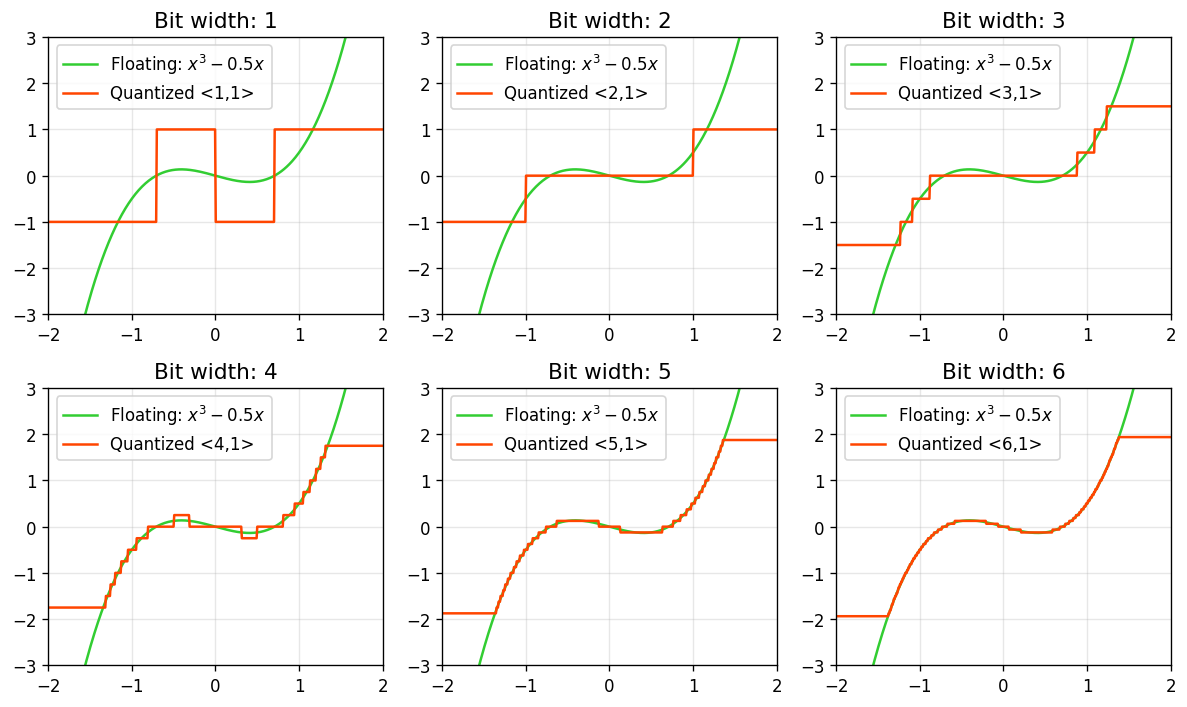

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from qkeras.quantizers import quantized_bits

fig, axs = plt.subplots(2, 3, figsize=(10, 6), dpi=120)
axs = axs.flatten()

# Input range
x_vals = np.linspace(-4, 4, 1000)
y_float = x_vals**3 - 0.5 * x_vals

# Bit widths in 2-bit increments
bit_widths = list(range(1, 7, 1))  

for i, bit_width in enumerate(bit_widths):

    # Floating curve
    axs[i].plot(x_vals, y_float, color='limegreen')

    # Quantized curve <bit_width,1>
    quantizer = quantized_bits(bit_width, 1, 1, alpha=1)
    y_quant = quantizer(y_float)

    axs[i].plot(x_vals, y_quant, color='orangered')

    axs[i].set_title(f"Bit width: {bit_width}", fontsize=13)
    axs[i].set_xlim(-2,2)
    axs[i].set_ylim(-3,3)
    axs[i].grid(alpha=0.3)

    axs[i].legend(["Floating: $x^3-0.5x$", f"Quantized <{bit_width},1>"], fontsize=10)

plt.tight_layout()
fig.savefig("cube.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
import numpy as np
import copy
import hls4ml
import ndjson
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from qkeras import QDense
from qkeras.quantizers import quantized_bits

# We will keep integer bits fixed at 1
bit_widths_qkeras = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
N_epochs = 2

hls_accuracy_qkeras_list = []
hls_summary_qkeras_list = []
y_pred_hls_qkeras_list = []
precision_labels_qkeras = []

for bit_width in bit_widths_qkeras:
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f" --> QKeras model with bit width: {bit_width}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

    # Build QKeras model
    qmodel = Sequential()
    
    qmodel.add(QDense(
        32, input_shape=(16,), name='fc1',
        kernel_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qmodel.add(Activation('relu', name='relu1'))

    qmodel.add(QDense(
        32, name='fc2',
        kernel_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qmodel.add(Activation('relu', name='relu2'))

    qmodel.add(QDense(
        32, name='fc3',
        kernel_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qmodel.add(Activation('relu', name='relu3'))

    qmodel.add(QDense(
        5, name='output',
        kernel_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qmodel.add(Activation('softmax', name='softmax'))

    # Compile and initialise with baseline weights
    adam = Adam(learning_rate=0.0001)
    qmodel.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

    # Start from floating-point baseline weights
    qmodel.set_weights(model.get_weights())

    # Train briefly (QAT fine-tuning)
    qmodel.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=N_epochs,
        validation_split=0.25,
        shuffle=True,
        verbose=0
    )

    # Build hls4ml config
    config_q = hls4ml.utils.config_from_keras_model(qmodel, granularity='name', backend='oneAPI')
    output_dir = f"model_qkeras_bw_{bit_width}"

    # Convert and compile
    hls_model_q = hls4ml.converters.convert_from_keras_model(
        qmodel,
        hls_config=config_q,
        backend='oneAPI',
        output_dir=output_dir,
        part='Agilex7')

    hls_model_q.compile()

    # Calculate accuracy
    X_test_contig = np.ascontiguousarray(X_test)
    y_hls = hls_model_q.predict(X_test_contig)

    y_pred_hls_qkeras_list.append(y_hls)
    precision_labels_qkeras.append(f"{bit_width} bits")

    accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))
    print(f"Accuracy: {accuracy:.4f}")
    hls_accuracy_qkeras_list.append(accuracy)

    # Build report and store summary
    hls_model_q.build(build_type='report')

    report_path = f"{output_dir}/build/myproject.report.prj/reports/resources/json/summary.ndjson"

    with open(report_path, "r") as f:
        summary = ndjson.load(f)

    hls_summary_qkeras_list.append(summary)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> QKeras model with bit width: 1
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qkeras_bw_1/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-0bf94295.so
[100%] Built target lib
Accuracy: 0.2051
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Addition

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> QKeras model with bit width: 2
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qkeras_bw_2/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-ee4eaff6.so
[100%] Built target lib
Accuracy: 0.2051
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex

...

[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> QKeras model with bit width: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qkeras_bw_15/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-abd57118.so
[100%] Built target lib
Accuracy: 0.7633
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agil

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> QKeras model with bit width: 16
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qkeras_bw_16/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-0d078987.so
[100%] Built target lib
Accuracy: 0.7635
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agil

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report


In [45]:
from sklearn.metrics import roc_auc_score
import numpy as np

n_classes = y_test.shape[1]

# Baseline float AUCs (from your trained float model)
float_auc_per_class = np.array([auc_g, auc_q, auc_t, auc_w, auc_z])
float_auc_macro = auc_macro

# Containers for QKeras AUC fractions
auc_fraction_per_class_qkeras = []
macro_auc_list_qkeras = []
macro_auc_fraction_qkeras = []

for y_pred_hls in y_pred_hls_qkeras_list:
    
    # Compute per-class AUC
    aucs = np.array([
        roc_auc_score(y_test[:, i], y_pred_hls[:, i])
        for i in range(n_classes)
    ])
    
    # Macro AUC
    auc_macro_fixed = aucs.mean()
    
    # Fraction (QKeras / float)
    auc_ratio = aucs / float_auc_per_class
    macro_ratio = auc_macro_fixed / float_auc_macro
    
    # Store
    auc_fraction_per_class_qkeras.append(auc_ratio)
    macro_auc_list_qkeras.append(auc_macro_fixed)
    macro_auc_fraction_qkeras.append(macro_ratio)

# Convert to numpy arrays
auc_fraction_per_class_qkeras = np.array(auc_fraction_per_class_qkeras)
macro_auc_list_qkeras = np.array(macro_auc_list_qkeras)
macro_auc_fraction_qkeras = np.array(macro_auc_fraction_qkeras)

print("Number of QKeras bit widths:", len(macro_auc_fraction_qkeras))

Number of QKeras bit widths: 16


In [94]:
float_auc_macro

0.9388904656639712

In [95]:
hls_accuracy_qkeras_list

[0.20506024096385542,
 0.32042168674698795,
 0.6999397590361446,
 0.7324698795180723,
 0.7505421686746988,
 0.7580722891566265,
 0.7578915662650603,
 0.7592168674698795,
 0.7598192771084338,
 0.7597590361445783,
 0.7596987951807229,
 0.7601204819277109,
 0.7601204819277109,
 0.7599397590361445,
 0.7598795180722892,
 0.7600602409638554]

In [46]:
resource_usage_qkeras = {}

for summ in hls_summary_qkeras_list:
    resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summ))[0]['columns'][1:-1]
    available = list(filter(lambda x: x["name"] == "Available", summ))[0]['data'][:-1]
    estimated_resources = list(filter(lambda x: x["name"] == "Total", summ))[0]['data'][:-1]

    for i, resource in enumerate(resource_names):
        r = resource.split(" ")[0].strip()
        usage_ratio = float(estimated_resources[i]) / float(available[i])

        if r not in resource_usage_qkeras:
            resource_usage_qkeras[r] = [usage_ratio]
        else:
            resource_usage_qkeras[r].append(usage_ratio)

In [97]:
bit_widths_qkeras = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

precision_labels_qkeras = []

for bit_width in bit_widths_qkeras:
    precision_labels_qkeras.append(f"{bit_width} bits")

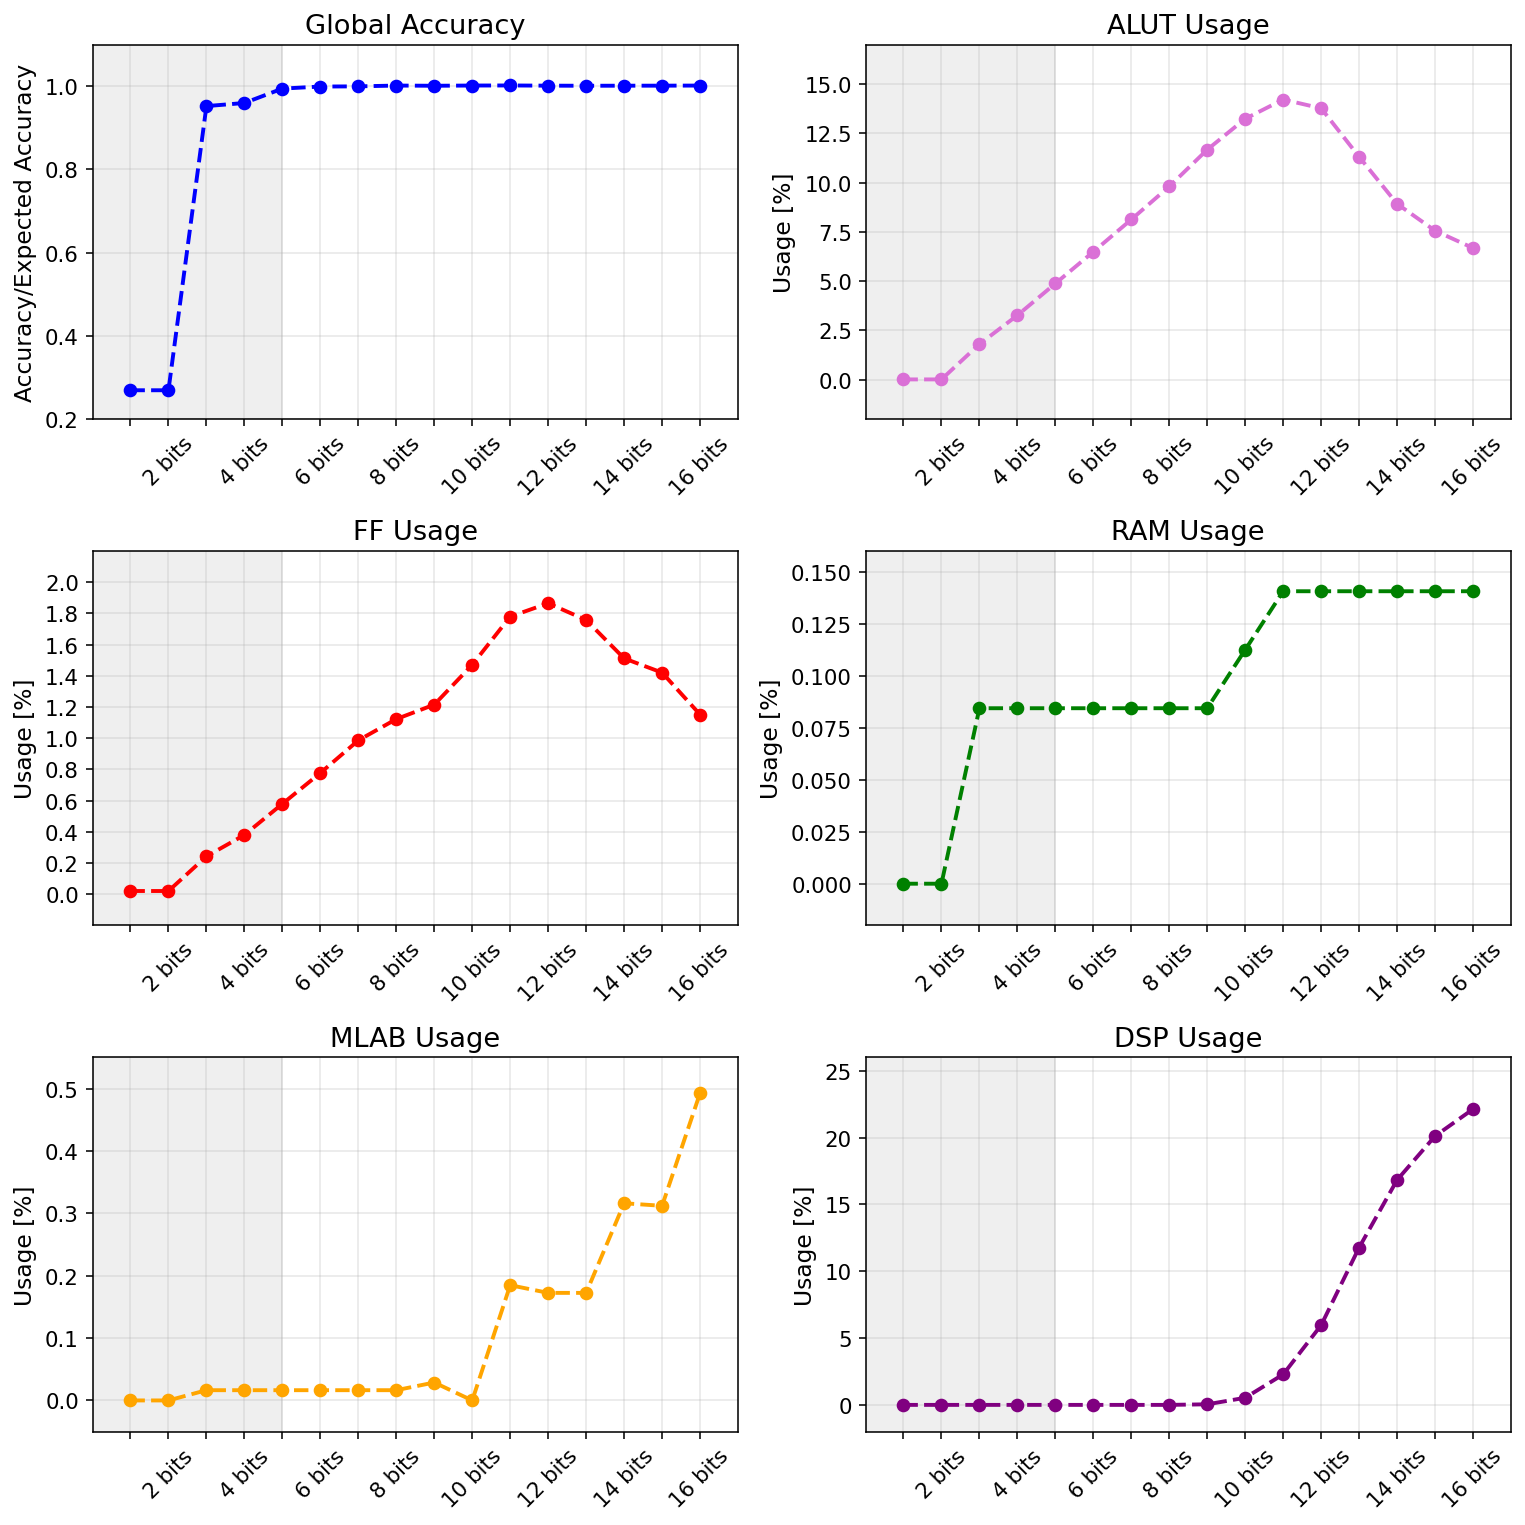

In [48]:
import matplotlib.pyplot as plt
import numpy as np

xx = precision_labels_qkeras
x = range(len(xx))
# Show only every second label
xtick_labels = [label if i % 2 == 1 else ""
                for i, label in enumerate(xx)]

fig, axes = plt.subplots(3, 2, figsize=(11, 11), dpi=140)
axes = axes.flatten()  


# Global AUC
axes[0].plot(x, hls_accuracy_qkeras_list/keras_accuracy, marker='o', linestyle='--', linewidth=2, color='blue')
axes[0].set_title("Global Accuracy", fontsize=14)
axes[0].set_ylabel("Accuracy/Expected Accuracy", fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.2, 1.1)

# ALUTs
axes[1].plot(x, 100*np.array(resource_usage_qkeras['ALUTs']),
             marker='o', linestyle='--', linewidth=2, color='orchid')
axes[1].set_title("ALUT Usage", fontsize=14)
axes[1].set_ylabel("Usage [%]", fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-2, 17)

# FFs
axes[2].plot(x, 100*np.array(resource_usage_qkeras['FFs']),
             marker='o', linestyle='--', linewidth=2, color='red')
axes[2].set_title("FF Usage", fontsize=14)
axes[2].set_ylabel("Usage [%]", fontsize=12)
ymax = axes[2].get_ylim()[1]  
axes[2].set_yticks(np.arange(0, ymax + 0.2, 0.2))
axes[2].set_xticks(x)
axes[2].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[2].grid(alpha=0.3)
axes[2].set_ylim(-0.2, 2.2)

# RAMs
axes[3].plot(x, 100*np.array(resource_usage_qkeras['RAMs']),
             marker='o', linestyle='--', linewidth=2, color='green')
axes[3].set_title("RAM Usage", fontsize=14)
axes[3].set_ylabel("Usage [%]", fontsize=12)
axes[3].set_xticks(x)
axes[3].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[3].grid(alpha=0.3)
axes[3].set_ylim(-0.02, 0.16)

# MLABs
axes[4].plot(x, 100*np.array(resource_usage_qkeras['MLABs']),
             marker='o', linestyle='--', linewidth=2, color='orange')
axes[4].set_title("MLAB Usage", fontsize=14)
axes[4].set_ylabel("Usage [%]", fontsize=12)
axes[4].set_xticks(x)
axes[4].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[4].grid(alpha=0.3)
axes[4].set_ylim(-0.05, 0.55)

# DSPs
axes[5].plot(x, 100*np.array(resource_usage_qkeras['DSPs']),
             marker='o', linestyle='--', linewidth=2, color='purple')
axes[5].set_title("DSP Usage", fontsize=14)
axes[5].set_ylabel("Usage [%]", fontsize=12)
axes[5].set_xticks(x)
axes[5].set_xticklabels(xtick_labels, rotation=45, size=12)
axes[5].grid(alpha=0.3)
axes[5].set_ylim(-2, 26)

for ax in axes:
    ax.axvspan(-1, 4, color='grey', alpha=0.12)

for ax in axes:
    ax.set_xlim(-1, 16)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)


plt.tight_layout()
fig.savefig("qkeras_new2.png", dpi=300, bbox_inches="tight")
plt.show()

## Part 5: Pruning

In this section we will discuss another method for reducing the resource usage, known as pruning (compression).

Weight matrices in neural networks can be huge. However not every weight contributes equally to the model performance. Pruning removes the low magnitude weights with very small impact to the classification performance.

On FPGAs, the weight matrices are known at compile time. Weights that are zero can be omitted by the compiler which of course reduces resource usage. 

To obtain sparse weight matrices, we can use L1 regularization to reduce weight magnitude. Then pruning can be scheduled to incrementaly remove and mask low magnitude weights.

Let's first import the relevant functionalities from keras.

In [49]:
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

Now we will set the pruning parameters (sparsity = 75%) and prune the baseline model (without QKeras training)

In [50]:
pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.9, begin_step=100, frequency=100)}
pmodel = prune.prune_low_magnitude(model, **pruning_params)

Let's then retrain the pruned network

In [51]:
adam = Adam(learning_rate=0.0001)
pmodel.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

pmodel.fit(
    X_train_val,
    y_train_val,
    batch_size=128,
    epochs=5,
    validation_split=0.25,
    shuffle=True,
    callbacks=[pruning_callbacks.UpdatePruningStep()],
)

Epoch 1/5
4767/4767 [==============================] - 24s 4ms/step - loss: 1.2337 - accuracy: 0.5121 - val_loss: 1.0931 - val_accuracy: 0.6202
Epoch 2/5
4767/4767 [==============================] - 19s 4ms/step - loss: 1.0194 - accuracy: 0.6261 - val_loss: 0.9440 - val_accuracy: 0.6316
Epoch 3/5
4767/4767 [==============================] - 19s 4ms/step - loss: 0.9105 - accuracy: 0.6307 - val_loss: 0.8907 - val_accuracy: 0.6316
Epoch 4/5
4767/4767 [==============================] - 18s 4ms/step - loss: 0.8772 - accuracy: 0.6498 - val_loss: 0.8656 - val_accuracy: 0.7354
Epoch 5/5
4767/4767 [==============================] - 19s 4ms/step - loss: 0.8451 - accuracy: 0.7329 - val_loss: 0.8310 - val_accuracy: 0.7309


In [52]:
# Strip pruning wrappers before converting for inference
pmodel = strip_pruning(pmodel)

In [53]:
# Print percentage sparsity (i.e. percentage of zero weights) for each layer
for i, l in zip(pmodel.get_weights(), pmodel.layers):
    print(f"{np.sum(i.flatten()==0)/i.flatten().shape[0]*100:.1f}% sparsity for layer {l.name}")

90.0% sparsity for layer fc1
0.0% sparsity for layer relu1
90.0% sparsity for layer fc2
0.0% sparsity for layer relu2
90.0% sparsity for layer fc3
0.0% sparsity for layer relu3
90.0% sparsity for layer output
0.0% sparsity for layer softmax


Now we have trained a pruned neural network with 75% of weights stripped (zero), that achieves roughly the same accuracy as the baseline model. To highlight the impact of this, we will convert the model to FPGA firmware using hls4ml, and examine the resource usage.

In [54]:
pconfig = hls4ml.utils.config_from_keras_model(pmodel, granularity='model', backend='oneAPI')
print("-----------------------------------")
print("Configuration")
print(pconfig)
print("-----------------------------------")
hls_pmodel = hls4ml.converters.convert_from_keras_model(
    pmodel, hls_config=pconfig, backend='oneAPI', output_dir='model_3/hls4ml_prj', part='Agilex7'
)

-----------------------------------
Configuration
{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}}
-----------------------------------


In [55]:
hls_pmodel.compile()

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_3/hls4ml_prj/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-a24214db.so
[100%] Built target lib


In [56]:
# Extract the accuracy on the test dataset
X_test = np.ascontiguousarray(X_test)
y_hls = hls_pmodel.predict(X_test)
hls_accuracy_prune = np.sum(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))/y_test.shape[0]
print(f"Achieved test accuracy of {(100 * hls_accuracy_prune):.2f}%")

Achieved test accuracy of 73.14%


In [93]:
### Trying out PolynomialDecay

In [94]:
pruning_params_poly = {"pruning_schedule": pruning_schedule.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=0.90,
    begin_step=100,
    end_step=1000
)}
pmodel_poly = prune.prune_low_magnitude(model, **pruning_params_poly)

In [95]:
adam = Adam(learning_rate=0.0001)
pmodel_poly.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

pmodel_poly.fit(
    X_train_val,
    y_train_val,
    batch_size=128,
    epochs=5,
    validation_split=0.25,
    shuffle=True,
    callbacks=[pruning_callbacks.UpdatePruningStep()],
)

Epoch 1/5
4767/4767 [==============================] - 22s 4ms/step - loss: 0.7337 - accuracy: 0.7483 - val_loss: 0.7356 - val_accuracy: 0.7476
Epoch 2/5
4767/4767 [==============================] - 19s 4ms/step - loss: 0.7309 - accuracy: 0.7489 - val_loss: 0.7329 - val_accuracy: 0.7489
Epoch 3/5
4767/4767 [==============================] - 19s 4ms/step - loss: 0.7287 - accuracy: 0.7496 - val_loss: 0.7308 - val_accuracy: 0.7492
Epoch 4/5
4767/4767 [==============================] - 20s 4ms/step - loss: 0.7269 - accuracy: 0.7501 - val_loss: 0.7293 - val_accuracy: 0.7494
Epoch 5/5
4767/4767 [==============================] - 19s 4ms/step - loss: 0.7254 - accuracy: 0.7506 - val_loss: 0.7278 - val_accuracy: 0.7500


In [96]:
# Strip pruning wrappers before converting for inference
pmodel_poly = strip_pruning(pmodel)

In [97]:
pconfig_poly = hls4ml.utils.config_from_keras_model(pmodel_poly, granularity='model', backend='oneAPI')
print("-----------------------------------")
print("Configuration")
print(pconfig_poly)
print("-----------------------------------")
hls_pmodel_poly = hls4ml.converters.convert_from_keras_model(
    pmodel_poly, hls_config=pconfig_poly, backend='oneAPI', output_dir='model_3/hls4ml_prj', part='Agilex7'
)

-----------------------------------
Configuration
{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}}
-----------------------------------


In [98]:
hls_pmodel_poly.compile()

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_3/hls4ml_prj/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-0ac7fc94.so
[100%] Built target lib


In [99]:
# Extract the accuracy on the test dataset
X_test = np.ascontiguousarray(X_test)
y_hls = hls_pmodel_poly.predict(X_test)
hls_accuracy_prune = np.sum(np.argmax(y_test, axis=1) == np.argmax(y_hls, axis=1))/y_test.shape[0]
print(f"Achieved test accuracy of {(100 * hls_accuracy_prune):.2f}%")

Achieved test accuracy of 75.17%


In [39]:
# Emulate the build
hls_pmodel.build(build_type='report')

/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_3/hls4ml_prj/build
[ 25%] To compile manually:
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/firmware/myproject.cpp -o CMakeFiles/report.dir/src/firmware/myproject.cpp.o
/opt/intel/oneapi/2025.0/bin/icpx -I../src -I../src/firmware -fsycl -fintelfpga -Wall -qactypes -Wno-unused-label -fconstexpr-steps=134217728 -DFPGA_HARDWARE -c ../src/myproject_test.cpp -o CMakeFiles/report.dir/src/myproject_

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report


{'report': {'HLS': {'total': {'alut': 41059,
    'reg': 8365,
    'ram': 6,
    'dsp': 10,
    'mlab': 4},
   'available': {'alut': '974400',
    'reg': '1948800',
    'ram': '7110',
    'dsp': '4510',
    'mlab': '24360'}},
  'Loop': {'worstFrequency': '200.0', 'worstII': '1', 'worstLatency': '26.0'}}}

In [40]:
# Extract the resource usage from summary json and print
with open("model_3/hls4ml_prj/build/myproject.report.prj/reports/resources/json/summary.ndjson", "r") as f:
    summary = ndjson.load(f)

resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summary))[0]['columns'][1:-1]
available = list(filter(lambda x: x["name"] == "Available", summary))[0]['data'][:-1]
estimated_resources = list(filter(lambda x: x["name"] == "Total", summary))[0]['data'][:-1]

print("~~~~~~~~~~~~~~ Resource usage (pruned model) ~~~~~~~~~~~~~~")
for i, resource in enumerate(resource_names):
    print(f"--> {resource}:")
    print(f"      * Available resource: {available[i]}")
    print(f"      * Used resource (estimated): {estimated_resources[i]}")
    print(f"      * Percentage of used resource (estimated): {100*float(estimated_resources[i])/float(available[i]):.2f}%")

~~~~~~~~~~~~~~ Resource usage (pruned model) ~~~~~~~~~~~~~~
--> ALUTs :
      * Available resource: 974400
      * Used resource (estimated): 41059
      * Percentage of used resource (estimated): 4.21%
--> FFs  :
      * Available resource: 1948800
      * Used resource (estimated): 8365
      * Percentage of used resource (estimated): 0.43%
--> RAMs :
      * Available resource: 7110
      * Used resource (estimated): 6
      * Percentage of used resource (estimated): 0.08%
--> DSPs :
      * Available resource: 4510
      * Used resource (estimated): 10
      * Percentage of used resource (estimated): 0.22%
--> MLABs:
      * Available resource: 24360
      * Used resource (estimated): 4
      * Percentage of used resource (estimated): 0.02%


In [57]:
import copy
import numpy as np
import hls4ml
import ndjson
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

sparsities = [0, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
N_epochs = 5

hls_accuracy_prune_list = []
hls_summary_prune_list = []
y_pred_hls_prune_list = []

for sparsity in sparsities:
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f" --> Pruning with sparsity: {sparsity}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

    # Applying pruning
    pruning_params = {
        "pruning_schedule":
        pruning_schedule.ConstantSparsity(
            sparsity,
            begin_step=100,
            frequency=100
        )
    }

    pmodel = prune.prune_low_magnitude(model, **pruning_params)

    # Compile and train
    adam = Adam(learning_rate=0.0001)
    pmodel.compile(
        optimizer=adam,
        loss=['categorical_crossentropy'],
        metrics=['accuracy']
    )

    pmodel.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=N_epochs,
        validation_split=0.25,
        shuffle=True,
        callbacks=[pruning_callbacks.UpdatePruningStep()],
        verbose=0
    )

    # Strip pruning wrappers
    pmodel = strip_pruning(pmodel)

    # Convert to hls4ml
    config = hls4ml.utils.config_from_keras_model(
        pmodel,
        granularity='model',
        backend='oneAPI'
    )

    output_dir = f"model_prune_{int(sparsity*100)}"

    hls_model = hls4ml.converters.convert_from_keras_model(
        pmodel,
        hls_config=config,
        backend='oneAPI',
        output_dir=output_dir,
        part='Agilex7'
    )

    hls_model.compile()

    # Accuracy evaluation
    X_test_contig = np.ascontiguousarray(X_test)
    y_hls = hls_model.predict(X_test_contig)
    y_pred_hls_prune_list.append(y_hls)
    
    accuracy = np.mean(
        np.argmax(y_test, axis=1) ==
        np.argmax(y_hls, axis=1))

    print(f"Accuracy: {accuracy:.4f}")
    hls_accuracy_prune_list.append(accuracy)

    # Build report
    hls_model.build(build_type='report')

    report_path = f"{output_dir}/build/myproject.report.prj/reports/resources/json/summary.ndjson"

    with open(report_path, "r") as f:
        summary = ndjson.load(f)

    hls_summary_prune_list.append(summary)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Pruning with sparsity: 0
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_prune_0/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-db3d66dc.so
[100%] Built target lib
Accuracy: 0.7518
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xscl

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Pruning with sparsity: 0.25
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_prune_25/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-1e4679af.so
[100%] Built target lib
Accuracy: 0.7544
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Pruning with sparsity: 0.5
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_prune_50/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-5f30a221.so
[100%] Built target lib
Accuracy: 0.7574
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_F

...

[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Pruning with sparsity: 0.975
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_prune_97/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-69866231.so
[100%] Built target lib
Accuracy: 0.6299
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 --> Pruning with sparsity: 0.99
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_prune_99/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-c8284fd7.so
[100%] Built target lib
Accuracy: 0.2958
/opt/intel/oneapi/2025.0/bin/icpx
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_

icpx: warning: appending to an existing archive 'myproject.report' [-Warchive-append]
Segmentation fault (core dumped)


[100%] Built target report


In [58]:

# Containers
auc_fraction_per_class_prune = []
macro_auc_list_prune = []
macro_auc_fraction_prune = []

for y_pred_hls in y_pred_hls_prune_list:
    
    # Per-class AUCs
    aucs = np.array([
        roc_auc_score(y_test[:, i], y_pred_hls[:, i])
        for i in range(n_classes)
    ])
    
    # Macro AUC
    auc_macro_pruned = aucs.mean()
    
    # Fractions (pruned / float baseline)
    auc_ratio = aucs / float_auc_per_class
    macro_ratio = auc_macro_pruned / float_auc_macro
    
    # Store
    auc_fraction_per_class_prune.append(auc_ratio)
    macro_auc_list_prune.append(auc_macro_pruned)
    macro_auc_fraction_prune.append(macro_ratio)

# Convert to arrays
auc_fraction_per_class_prune = np.array(auc_fraction_per_class_prune)
macro_auc_list_prune = np.array(macro_auc_list_prune)
macro_auc_fraction_prune = np.array(macro_auc_fraction_prune)

print("Number of sparsity points:", len(macro_auc_fraction_prune))

Number of sparsity points: 10


In [59]:
# SOLUTION: extract resource usage from summary jsons
resource_usage_prune_list = {}
for summ in hls_summary_prune_list:
    resource_names = list(filter(lambda x: x["name"] == "Estimated Resource Usage", summ))[0]['columns'][1:-1]
    available = list(filter(lambda x: x["name"] == "Available", summ))[0]['data'][:-1]
    estimated_resources = list(filter(lambda x: x["name"] == "Total", summ))[0]['data'][:-1]

    for i, resource in enumerate(resource_names):
        r = resource.split(" ")[0]
        if r not in resource_usage_prune_list:
            resource_usage_prune_list[r] = [float(estimated_resources[i])/float(available[i])]
        else:
            resource_usage_prune_list[r].append(float(estimated_resources[i])/float(available[i]))

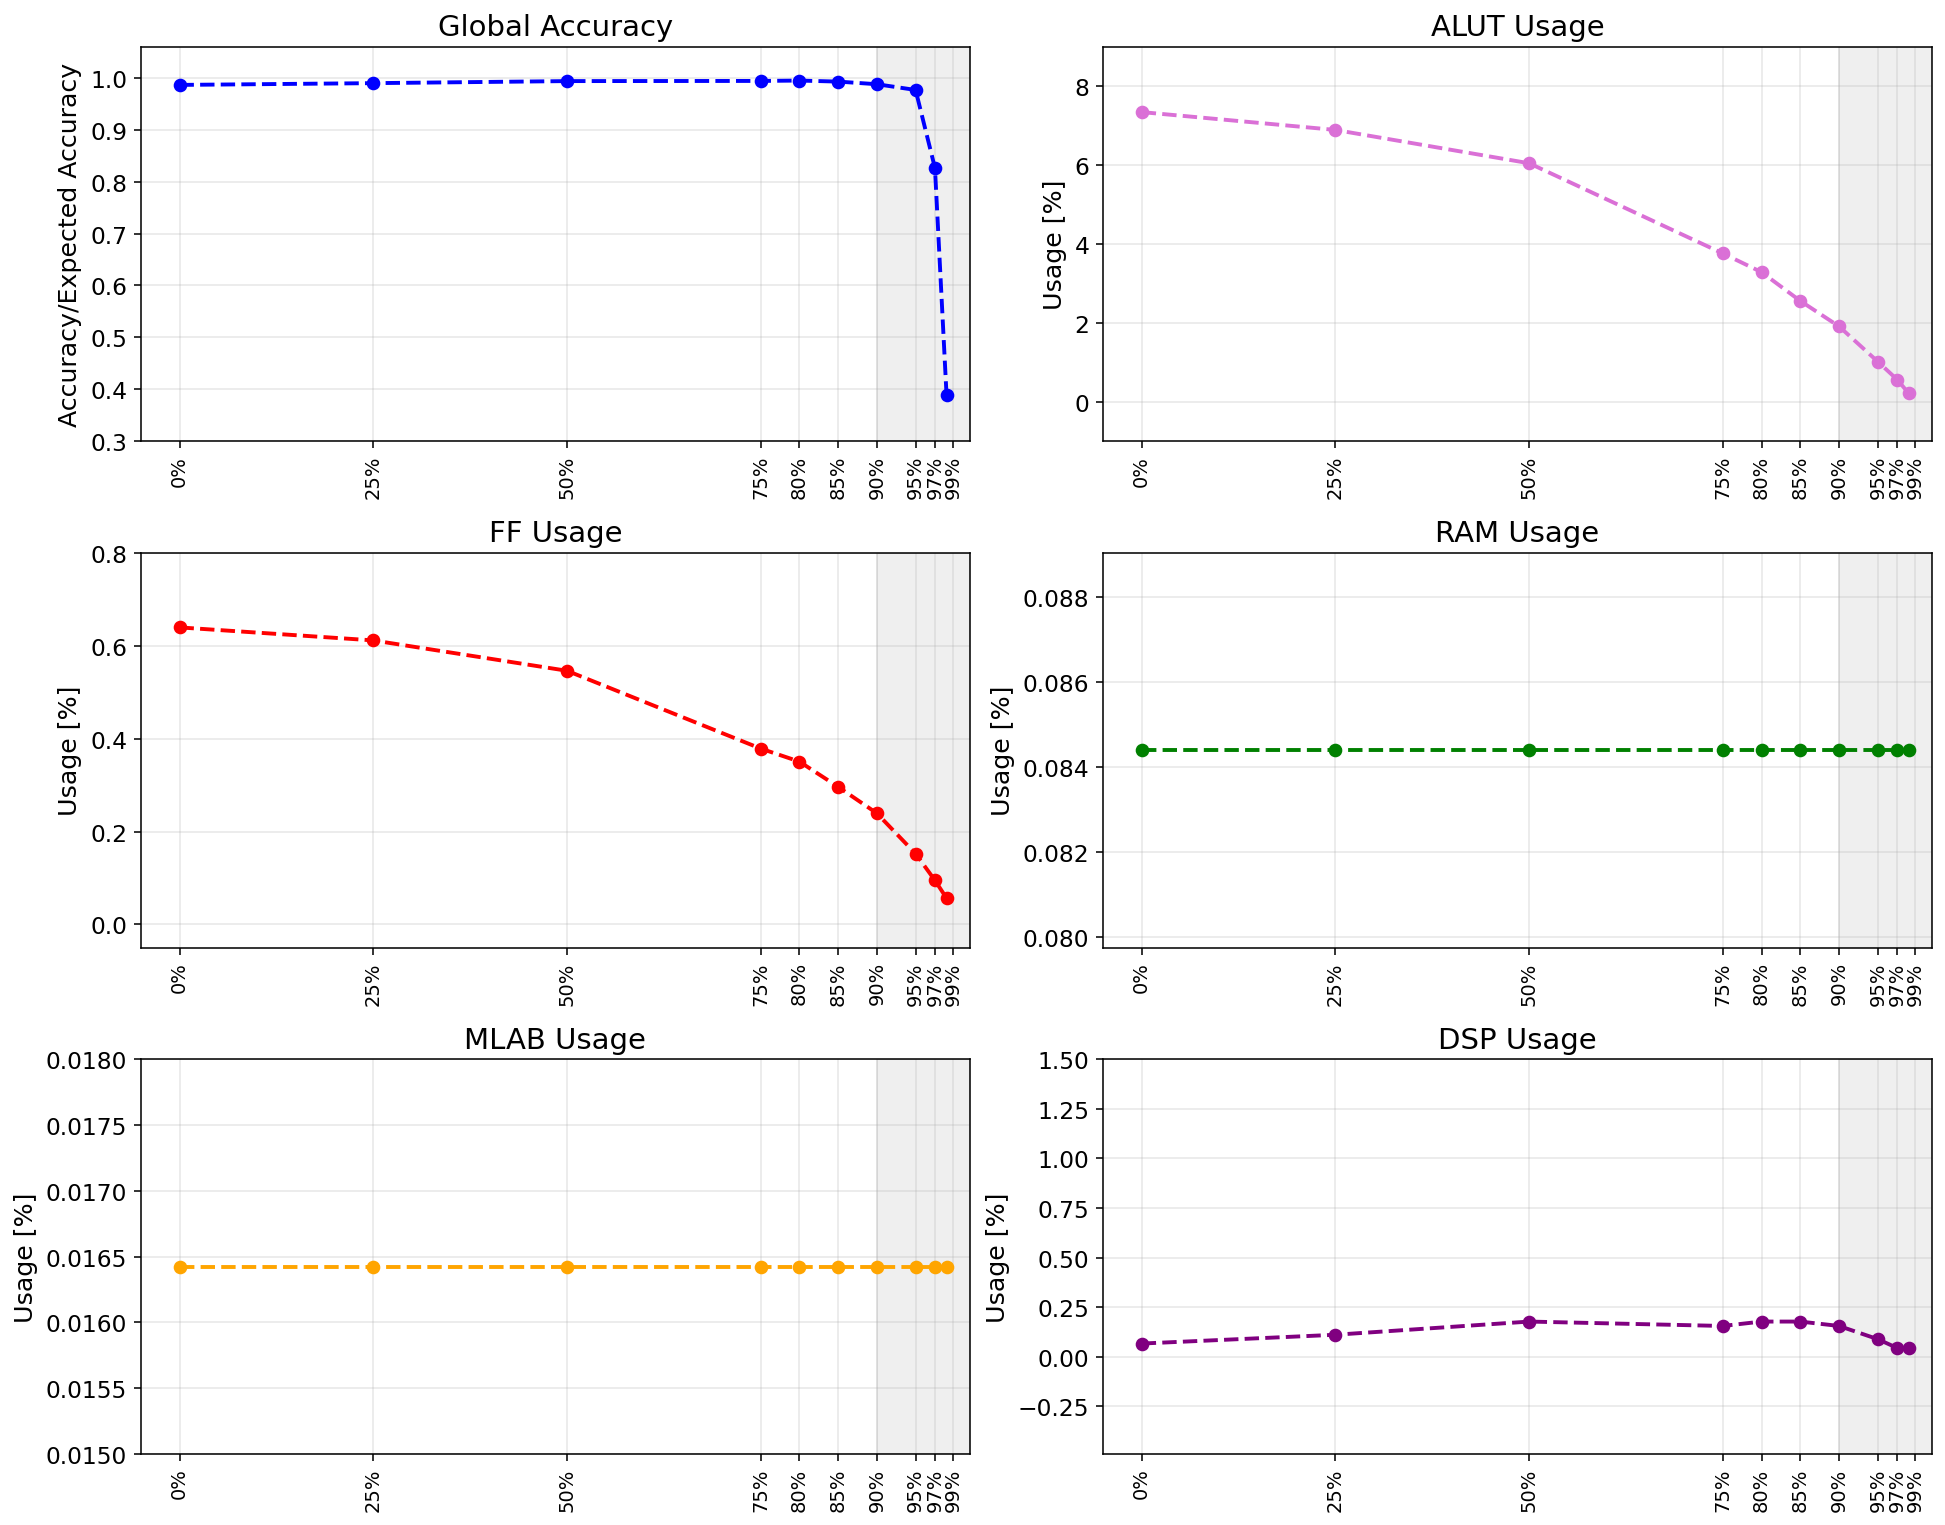

In [96]:
import matplotlib.pyplot as plt
import numpy as np

x = sparsities
xtick_labels = [f"{int(s*100)}%" for s in sparsities]
#x = np.arange(len(sparsities))   # evenly spaced positions
#xtick_labels = [f"{s*100:.1f}%" for s in sparsities]

fig, axes = plt.subplots(3, 2, figsize=(14, 11), dpi=140)
axes = axes.flatten()

tick_positions = list(x)
tick_positions[-1] = tick_positions[-1] + 0.008  # shift 99% slightly right

# AUC
axes[0].plot(x, hls_accuracy_prune_list/keras_accuracy,
             marker='o', linestyle='--', linewidth=2, color='blue')

axes[0].set_title("Global Accuracy", fontsize=15)
axes[0].set_ylabel("Accuracy/Expected Accuracy", fontsize=13)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(xtick_labels, rotation=90)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-0.05, 1.02)
axes[0].set_ylim(0.3, 1.06)

# ALUTs
axes[1].plot(x, 100*np.array(resource_usage_prune_list['ALUTs']),
             marker='o', linestyle='--', linewidth=2, color='orchid')

axes[1].set_title("ALUT Usage", fontsize=15)
axes[1].set_ylabel("Usage [%]", fontsize=13)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(xtick_labels, rotation=90)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-0.05, 1.02)
axes[1].set_ylim(-1, 9)

# FFs
axes[2].plot(x, 100*np.array(resource_usage_prune_list['FFs']),
             marker='o', linestyle='--', linewidth=2, color='red')

axes[2].set_title("FF Usage", fontsize=15)
axes[2].set_ylabel("Usage [%]", fontsize=13)
axes[2].set_xticks(tick_positions)
axes[2].set_xticklabels(xtick_labels, rotation=90)
axes[2].grid(alpha=0.3)
axes[2].set_xlim(-0.05, 1.02)
axes[2].set_ylim(-0.05, 0.8)

# RAMs
axes[3].plot(x, 100*np.array(resource_usage_prune_list['RAMs']),
             marker='o', linestyle='--', linewidth=2, color='green')

axes[3].set_title("RAM Usage", fontsize=15)
axes[3].set_ylabel("Usage [%]", fontsize=13)
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels(xtick_labels, rotation=90)
axes[3].grid(alpha=0.3)
axes[3].set_xlim(-0.05, 1.02)

# MLABs
axes[4].plot(x, 100*np.array(resource_usage_prune_list['MLABs']),
             marker='o', linestyle='--', linewidth=2, color='orange')

axes[4].set_title("MLAB Usage", fontsize=15)
axes[4].set_ylabel("Usage [%]", fontsize=13)
axes[4].set_xticks(tick_positions)
axes[4].set_xticklabels(xtick_labels, rotation=90)
axes[4].grid(alpha=0.3)
axes[4].set_xlim(-0.05, 1.02)
axes[4].set_ylim(0.015, 0.018)

# DSPs
axes[5].plot(x, 100*np.array(resource_usage_prune_list['DSPs']),
             marker='o', linestyle='--', linewidth=2, color='purple')

axes[5].set_title("DSP Usage", fontsize=15)
axes[5].set_ylabel("Usage [%]", fontsize=13)
axes[5].set_xticks(tick_positions)
axes[5].set_xticklabels(xtick_labels, rotation=90)
axes[5].grid(alpha=0.3)
axes[5].set_xlim(-0.05, 1.02)
axes[5].set_ylim(-0.49, 1.5)


for ax in axes:
    ax.axvspan(0.90, 1.02, color='grey', alpha=0.12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=10)
    
plt.tight_layout()
fig.savefig("pruning_scan.png", dpi=300, bbox_inches="tight")
plt.show()


## Quantisation + Pruning

In [ ]:
import numpy as np
import hls4ml
import ndjson
import copy

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1

from qkeras import QDense
from qkeras.quantizers import quantized_bits

import tensorflow_model_optimization as tfmot

prune = tfmot.sparsity.keras

bit_widths_qp_scan = list(range(1, 9))   # 1 → 8 bits
fixed_sparsity_qp = 0.90
epochs_qp = 3

accuracy_qp_scan = []
summary_qp_scan = []
predictions_qp_scan = []
labels_qp_scan = []

for bit_width_qp in bit_widths_qp_scan:

    print("=================================================")
    print(f" --> Quantization + 90% pruning | bit width: {bit_width_qp}")
    print("=================================================")

    # Build QKeras model
    qprune_model = Sequential()

    qprune_model.add(QDense(
        32, input_shape=(16,), name='fc1_qp',
        kernel_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qprune_model.add(Activation('relu', name='relu1_qp'))

    qprune_model.add(QDense(
        32, name='fc2_qp',
        kernel_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qprune_model.add(Activation('relu', name='relu2_qp'))

    qprune_model.add(QDense(
        32, name='fc3_qp',
        kernel_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qprune_model.add(Activation('relu', name='relu3_qp'))

    qprune_model.add(QDense(
        5, name='output_qp',
        kernel_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        bias_quantizer=quantized_bits(bit_width_qp, 1, 1, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001)
    ))
    qprune_model.add(Activation('softmax', name='softmax_qp'))

    
    # Initialise with float baseline weights
    qprune_model.set_weights(model.get_weights())

    qprune_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Short QAT fine-tune
    qprune_model.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=epochs_qp,
        validation_split=0.25,
        shuffle=True,
        verbose=0
    )

    
    # Apply 90% pruning (FIXED VERSION)
    
    pruning_params_qp = {
        "pruning_schedule": prune.ConstantSparsity(
            fixed_sparsity_qp,
            begin_step=0,
            frequency=100
        )
    }

    qprune_model_wrapped = prune.prune_low_magnitude(
        qprune_model,
        **pruning_params_qp
    )

    qprune_model_wrapped.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    qprune_model_wrapped.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=epochs_qp,
        validation_split=0.25,
        shuffle=True,
        callbacks=[prune.UpdatePruningStep()],
        verbose=0
    )

    # Strip pruning wrappers
    qprune_model_final = prune.strip_pruning(qprune_model_wrapped)

    # Convert to hls4ml
    
    config_qp = hls4ml.utils.config_from_keras_model(
        qprune_model_final,
        granularity='name',
        backend='oneAPI'
    )

    output_dir_qp = f"model_qp_90sparsity_bw_{bit_width_qp}"

    hls_model_qp = hls4ml.converters.convert_from_keras_model(
        qprune_model_final,
        hls_config=config_qp,
        backend='oneAPI',
        output_dir=output_dir_qp,
        part='Agilex7'
    )

    hls_model_qp.compile()

    # Evaluate

    X_test_contig = np.ascontiguousarray(X_test)
    y_pred_qp = hls_model_qp.predict(X_test_contig)

    predictions_qp_scan.append(y_pred_qp)
    labels_qp_scan.append(f"{bit_width_qp} bits")

    acc_qp = np.mean(
        np.argmax(y_test, axis=1) ==
        np.argmax(y_pred_qp, axis=1)
    )

    print(f"Accuracy: {acc_qp:.4f}")
    accuracy_qp_scan.append(acc_qp)

    # Resource report
   
    hls_model_qp.build(build_type='report')

    report_path_qp = (
        f"{output_dir_qp}/build/myproject.report.prj/"
        "reports/resources/json/summary.ndjson"
    )

    with open(report_path_qp, "r") as f:
        summary_qp = ndjson.load(f)

    summary_qp_scan.append(summary_qp)

 --> Quantization + 90% pruning | bit width: 1


/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
/home/kajka/miniconda3/envs/oneapi-env/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (1.1s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qp_90sparsity_bw_1/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproject_bridge.cpp.o
[100%] Linking CXX shared library libmyproject-e94e2897.s

Segmentation fault (core dumped)


[100%] Built target report
 --> Quantization + 90% pruning | bit width: 2
/opt/intel/oneapi/2025.0/bin/icpx
-- The CXX compiler identification is IntelLLVM 2025.0.4
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /opt/intel/oneapi/2025.0/bin/icpx - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring the design to run on FPGA board Agilex7
-- Additional USER_FPGA_FLAGS=-Xsoptimize=latency;-Xsclock=5ns;-Wno-unused-label
-- Additional USER_FLAGS=-Wno-unused-label;-fconstexpr-steps=134217728
-- Additional USER_INCLUDE_PATHS=src;src/firmware
-- Additional USER_LIB_PATHS=
-- Additional USER_LIBS=
-- Configuring done (1.1s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kajka/local/acceleratingai-aims25/model_qp_90sparsity_bw_2/build
[ 33%] Building CXX object CMakeFiles/lib.dir/src/firmware/myproject.cpp.o
[ 66%] Building CXX object CMakeFiles/lib.dir/src/myproj

make[3]: *** [CMakeFiles/report.dir/build.make:113: myproject.report] Interrupt
make[2]: *** [CMakeFiles/Makefile2:180: CMakeFiles/report.dir/all] Interrupt
make[1]: *** [CMakeFiles/Makefile2:187: CMakeFiles/report.dir/rule] Interrupt
make: *** [Makefile:163: report] Interrupt


Error in callback <function _draw_all_if_interactive at 0x7a7e99b06680> (for post_execute), with arguments args (),kwargs {}:
